In [1]:
print("Bu çalışmada Coimbra Breast Cancer veri seti kullanılmıştır.")
print("Problem türü: İkili sınıflandırma")
print("Hedef değişken: Classification")
print("1 = Sağlıklı, 2 = Hasta")

Bu çalışmada Coimbra Breast Cancer veri seti kullanılmıştır.
Problem türü: İkili sınıflandırma
Hedef değişken: Classification
1 = Sağlıklı, 2 = Hasta


In [2]:
# Gerekli Kütüphaneler 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

In [3]:
# Görsel stil
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_theme(style="whitegrid")

In [4]:
# veri setinin okunması 
# df = pd.read_csv('dataR2.csv')
df = pd.read_csv("C:\\breast+cancer+coimbra\\dataR2.csv")
df_raw = df.copy()   # ham veri kopyası

In [5]:
print("VERİ SETİ GENEL BİLGİLERİ")
print(f"\nVeri Boyutu (Satır × Sütun) : {df.shape[0]} × {df.shape[1]}")
print(f"\nSütun Adları:\n  {list(df.columns)}")

VERİ SETİ GENEL BİLGİLERİ

Veri Boyutu (Satır × Sütun) : 116 × 10

Sütun Adları:
  ['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP.1', 'Classification']


In [6]:
print(f"\nVeri Türleri:")
print(df.dtypes.to_string())


Veri Türleri:
Age                 int64
BMI               float64
Glucose             int64
Insulin           float64
HOMA              float64
Leptin            float64
Adiponectin       float64
Resistin          float64
MCP.1             float64
Classification      int64


In [7]:
print(f"\nİlk 5 Satır:")
print(df.head().to_string(index=False))


İlk 5 Satır:
 Age       BMI  Glucose  Insulin     HOMA  Leptin  Adiponectin  Resistin   MCP.1  Classification
  48 23.500000       70    2.707 0.467409  8.8071     9.702400   7.99585 417.114               1
  83 20.690495       92    3.115 0.706897  8.8438     5.429285   4.06405 468.786               1
  82 23.124670       91    4.498 1.009651 17.9393    22.432040   9.27715 554.697               1
  68 21.367521       77    3.226 0.612725  9.8827     7.169560  12.76600 928.220               1
  86 21.111111       92    3.549 0.805386  6.6994     4.819240  10.57635 773.920               1


In [8]:
print(f"\nSınıf Dağılımı:")
print(f"  Sağlıklı (Classification=1) : {(df['Classification']==1).sum()} adet")
print(f"  Hasta    (Classification=2) : {(df['Classification']==2).sum()} adet")


Sınıf Dağılımı:
  Sağlıklı (Classification=1) : 52 adet
  Hasta    (Classification=2) : 64 adet


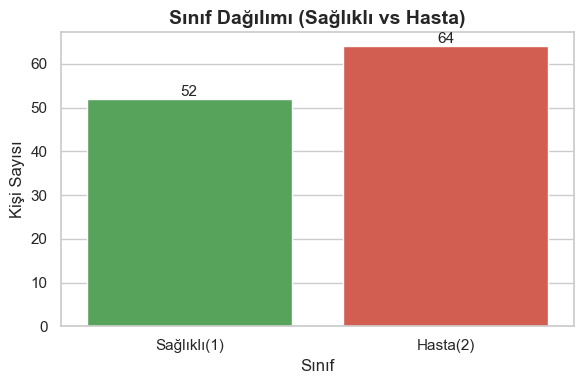

In [9]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='Classification',
    data=df,
    palette=['#4CAF50', '#E74C3C']  
)

# X ekseni etiketleri
ax.set_xticklabels(['Sağlıklı(1)', 'Hasta(2)'])

# Başlık ve eksen isimleri
plt.title("Sınıf Dağılımı (Sağlıklı vs Hasta)", fontsize=14, weight='bold')
plt.xlabel("Sınıf")
plt.ylabel("Kişi Sayısı")

# Bar üstüne sayı yazdır
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

sns.set_style("whitegrid")
plt.tight_layout()
plt.show()

In [10]:
# istatistiksel analiz
print("VERİ SETİNİN İSTATİSTİKSEL ÖZETİ")
print(df.describe().T.round(3).to_string())

# Çeyreklikler (Q1, Q2, Q3)
print("\nÇeyreklikler:")
print(df.drop('Classification', axis=1).quantile([0.25, 0.50, 0.75]).round(3).to_string())


VERİ SETİNİN İSTATİSTİKSEL ÖZETİ
                count     mean      std     min      25%      50%      75%       max
Age             116.0   57.302   16.113  24.000   45.000   56.000   71.000    89.000
BMI             116.0   27.582    5.020  18.370   22.973   27.662   31.241    38.579
Glucose         116.0   97.793   22.525  60.000   85.750   92.000  102.000   201.000
Insulin         116.0   10.012   10.068   2.432    4.359    5.924   11.189    58.460
HOMA            116.0    2.695    3.642   0.467    0.918    1.381    2.858    25.050
Leptin          116.0   26.615   19.183   4.311   12.314   20.271   37.378    90.280
Adiponectin     116.0   10.181    6.843   1.656    5.474    8.353   11.816    38.040
Resistin        116.0   14.726   12.391   3.210    6.882   10.828   17.755    82.100
MCP.1           116.0  534.647  345.913  45.843  269.978  471.322  700.085  1698.440
Classification  116.0    1.552    0.499   1.000    1.000    2.000    2.000     2.000

Çeyreklikler:
       Age     BM

In [11]:
# Dağılım şekli analizi
print("\nÇARPIKLIK (Skewness) ANALİZİ:")
print(df.drop('Classification', axis=1).skew().round(3).to_string())


ÇARPIKLIK (Skewness) ANALİZİ:
Age            0.018
BMI            0.170
Glucose        2.593
Insulin        2.578
HOMA           3.812
Leptin         1.310
Adiponectin    1.818
Resistin       2.577
MCP.1          1.424


In [12]:
print("\nBASIKLIK (Kurtosis) ANALİZİ:")
print(df.drop('Classification', axis=1).kurtosis().round(3).to_string())


BASIKLIK (Kurtosis) ANALİZİ:
Age            -0.983
BMI            -0.923
Glucose         8.988
Insulin         7.502
HOMA           17.591
Leptin          1.434
Adiponectin     3.929
Resistin        8.909
MCP.1           2.582


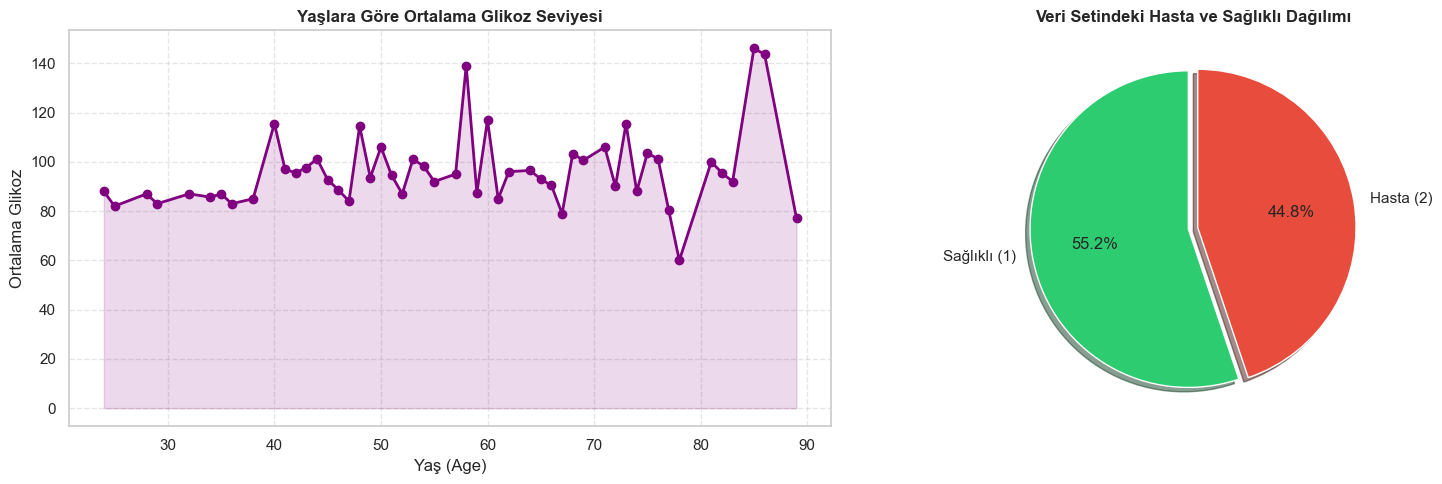

In [13]:
# Yaşa Göre Ortalama Glikoz
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

yas_glikoz = df.groupby('Age')['Glucose'].mean().reset_index()
axes[0].plot(yas_glikoz['Age'], yas_glikoz['Glucose'],
             marker='o', color='purple', linewidth=2, markersize=6)
axes[0].fill_between(yas_glikoz['Age'], yas_glikoz['Glucose'],
                     alpha=0.15, color='purple')
axes[0].set_title("Yaşlara Göre Ortalama Glikoz Seviyesi", fontweight='bold')
axes[0].set_xlabel("Yaş (Age)")
axes[0].set_ylabel("Ortalama Glikoz")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Sınıf Dağılımı (Pasta)
sinif_sayilari = df['Classification'].value_counts()
axes[1].pie(sinif_sayilari,
            labels=['Sağlıklı (1)', 'Hasta (2)'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            explode=(0.03, 0.03), shadow=True)
axes[1].set_title("Veri Setindeki Hasta ve Sağlıklı Dağılımı", fontweight='bold')

plt.tight_layout()
plt.show()

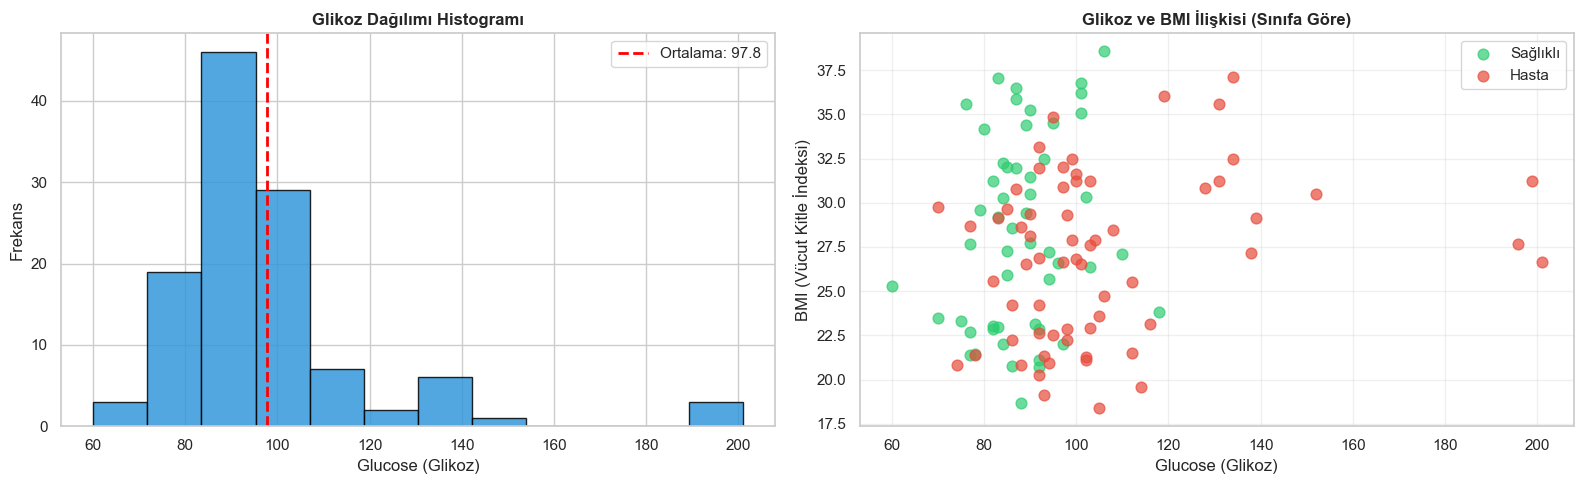

In [14]:
#  Glikoz Histogramı 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['Glucose'], bins=12, color='#3498db', edgecolor='black', alpha=0.85)
axes[0].axvline(df['Glucose'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Ortalama: {df["Glucose"].mean():.1f}')
axes[0].set_xlabel("Glucose (Glikoz)")
axes[0].set_ylabel("Frekans")
axes[0].set_title("Glikoz Dağılımı Histogramı", fontweight='bold')
axes[0].legend()

# Glikoz – BMI Saçılım 
renkmap = {1: '#2ecc71', 2: '#e74c3c'}
for sinif, renk in renkmap.items():
    alt = df[df['Classification'] == sinif]
    lbl = 'Sağlıklı' if sinif == 1 else 'Hasta'
    axes[1].scatter(alt['Glucose'], alt['BMI'], c=renk, alpha=0.7, label=lbl, s=60)
axes[1].set_xlabel("Glucose (Glikoz)")
axes[1].set_ylabel("BMI (Vücut Kitle İndeksi)")
axes[1].set_title("Glikoz ve BMI İlişkisi (Sınıfa Göre)", fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

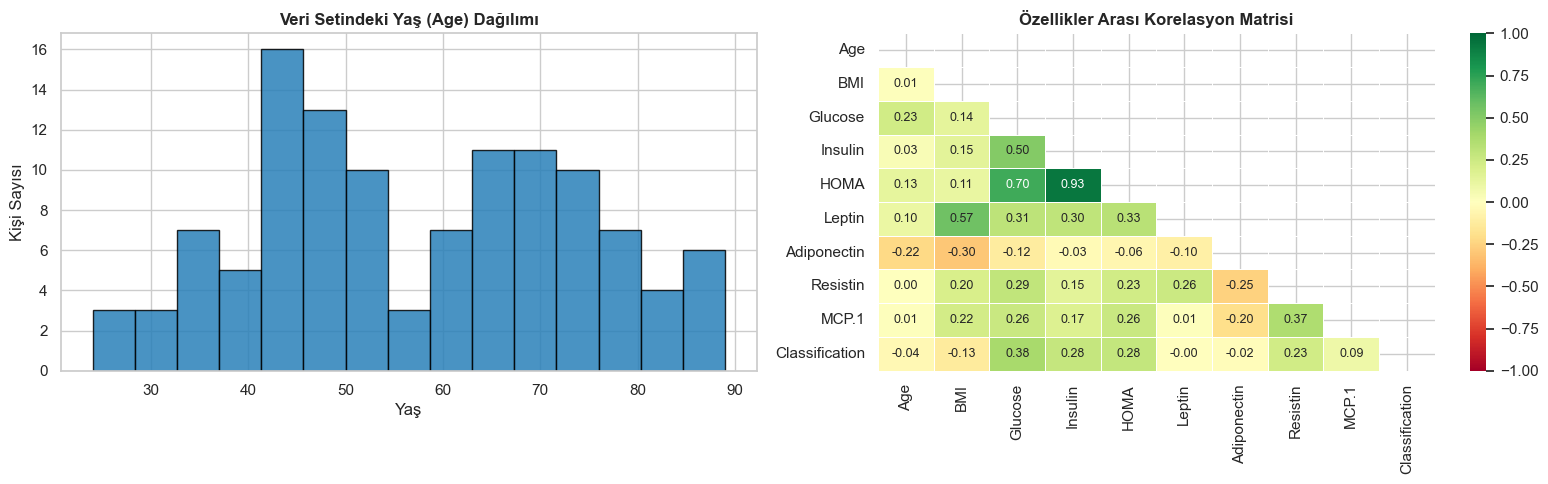

In [15]:
# Yaş Histogramı
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['Age'], bins=15, color='#2980b9', edgecolor='black', alpha=0.85)
axes[0].set_title("Veri Setindeki Yaş (Age) Dağılımı", fontweight='bold')
axes[0].set_xlabel("Yaş")
axes[0].set_ylabel("Kişi Sayısı")

# Korelasyon Matrisi
korelasyon = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(korelasyon, dtype=bool))
sns.heatmap(korelasyon, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9}, ax=axes[1])
axes[1].set_title("Özellikler Arası Korelasyon Matrisi", fontweight='bold')

plt.tight_layout()
plt.show()

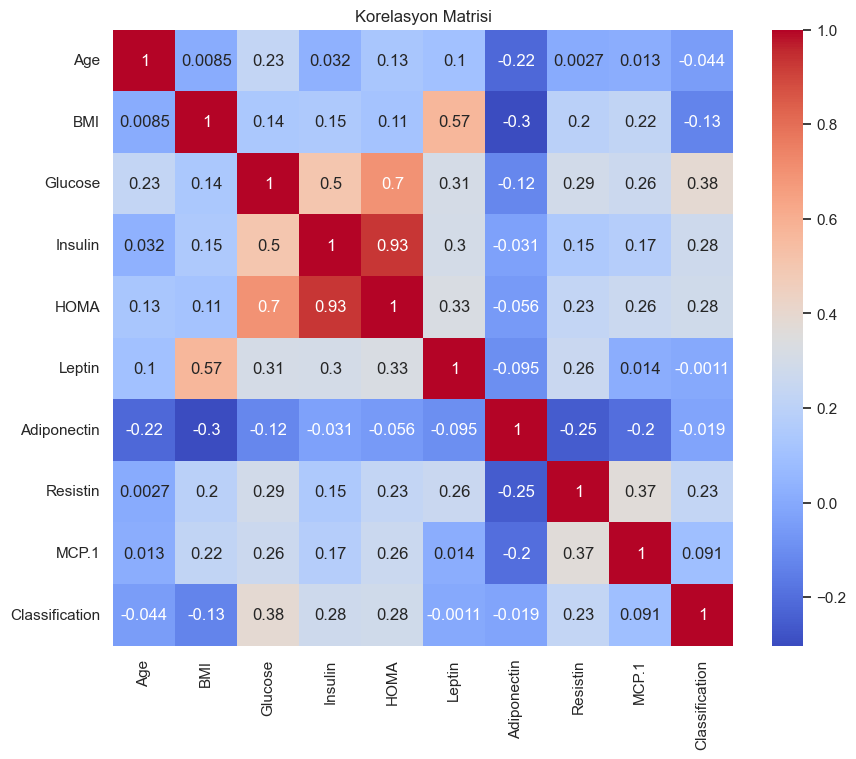

In [16]:
# özellikler arası ilişki Korelasyon Isı Haritası (Heatmap)
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Korelasyon Matrisi")
plt.show()

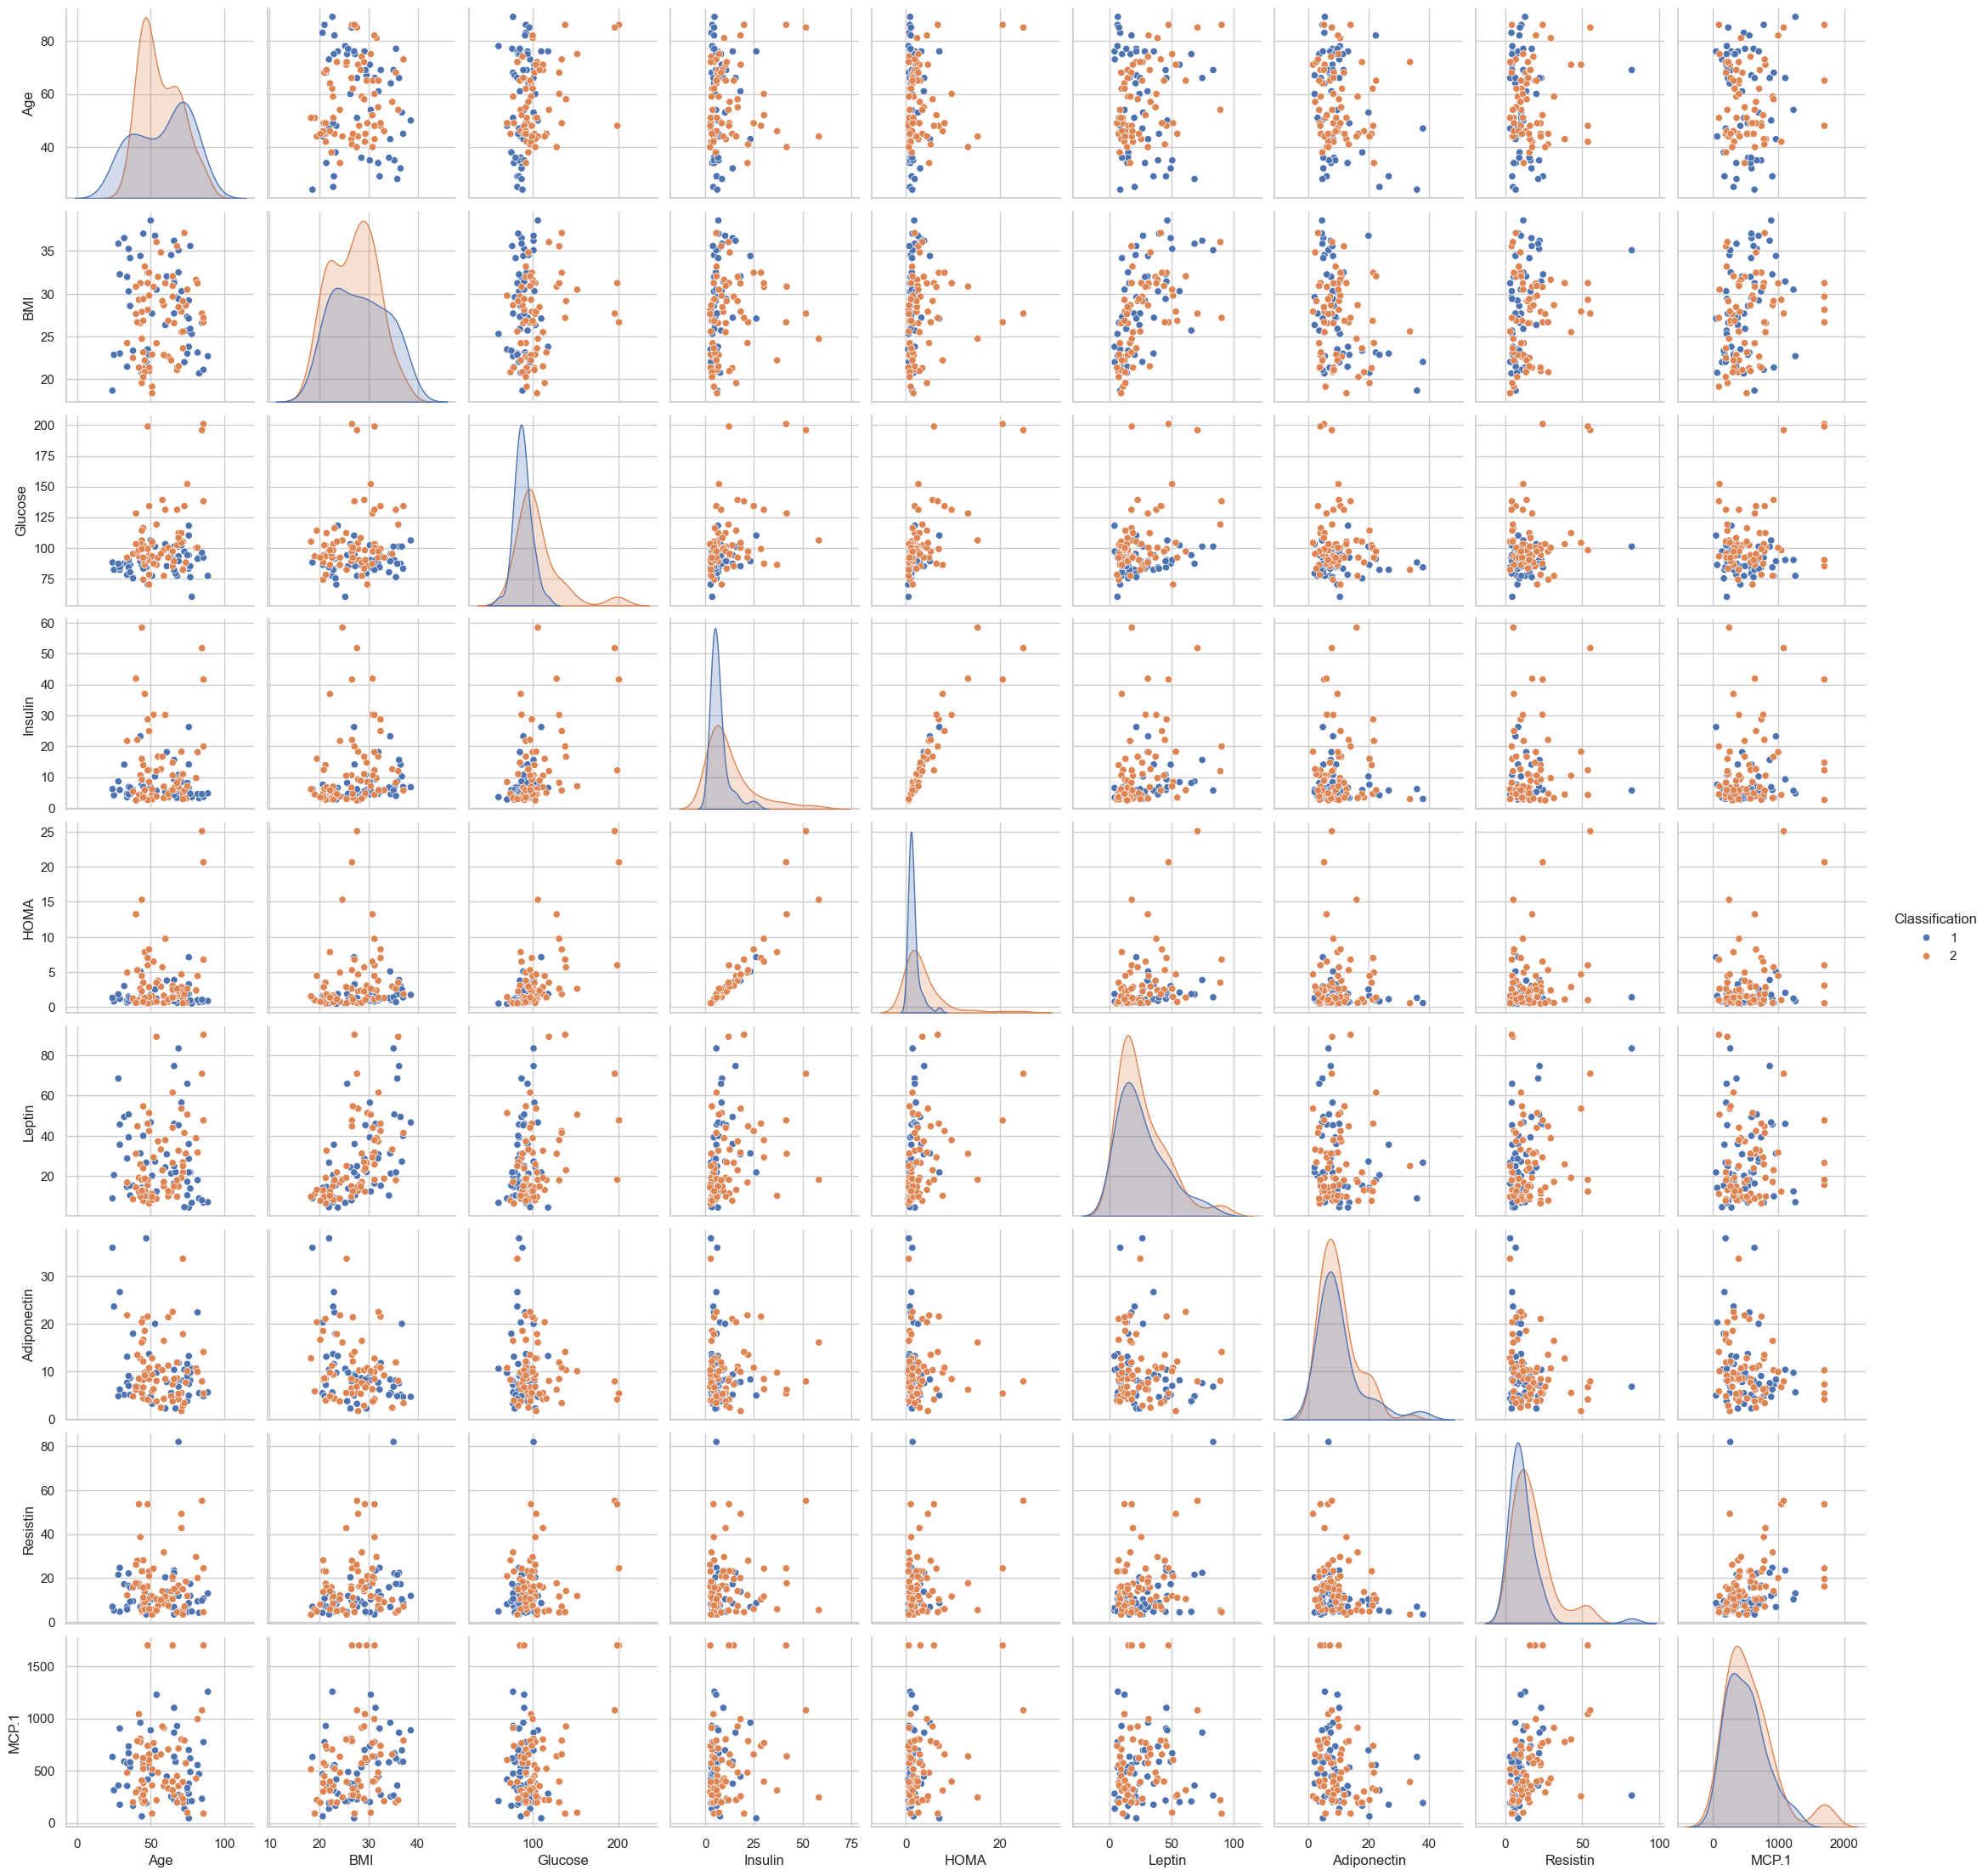

In [17]:
# özellikler arası ilişki
df["Classification"] = df["Classification"].astype("category")
sns.pairplot(df, hue="Classification")
plt.show()

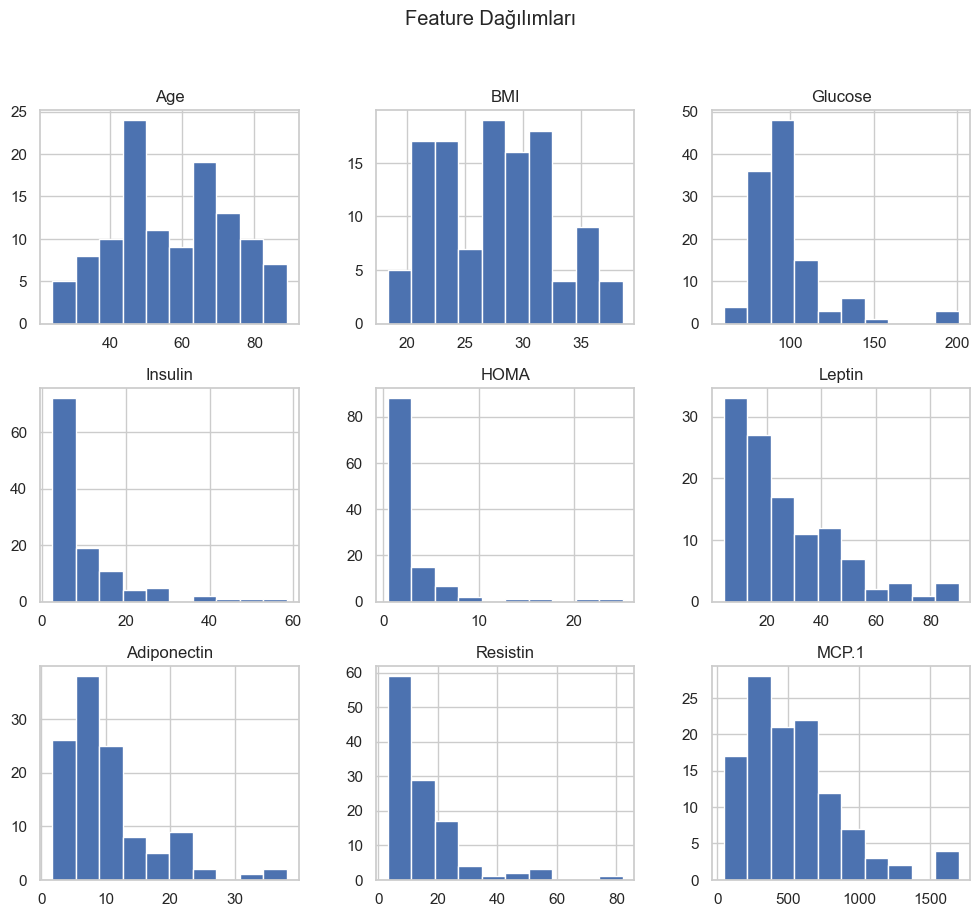

In [18]:
# x ekseni feature değerleri 
# y ekseni frekans yani değer veri setinde kaç defa geçtiğini gösteriyor.
df.hist(figsize=(12,10))
plt.suptitle("Feature Dağılımları")
plt.show()

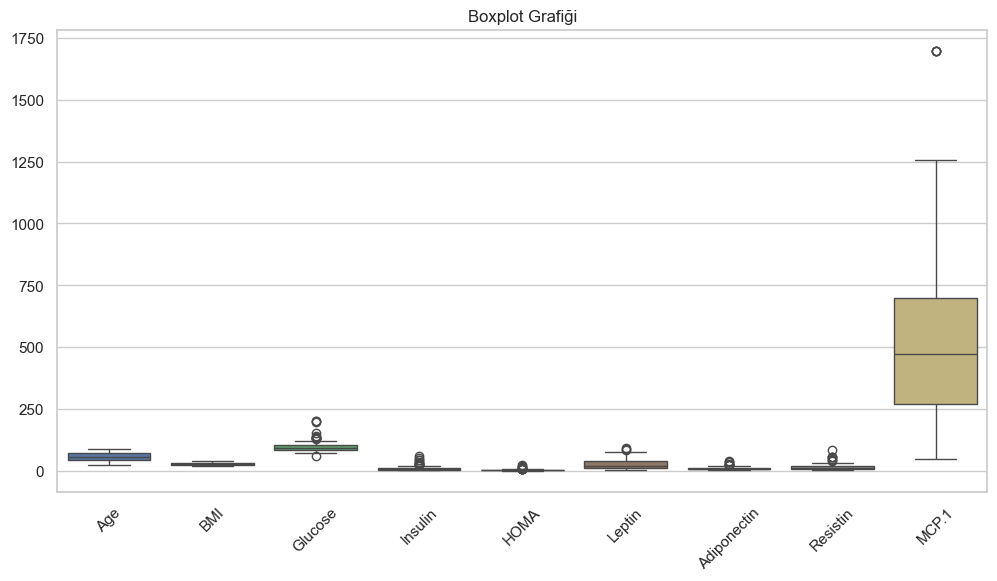

In [19]:
# aykırı değerler var mı görmek için
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot Grafiği")
plt.show()

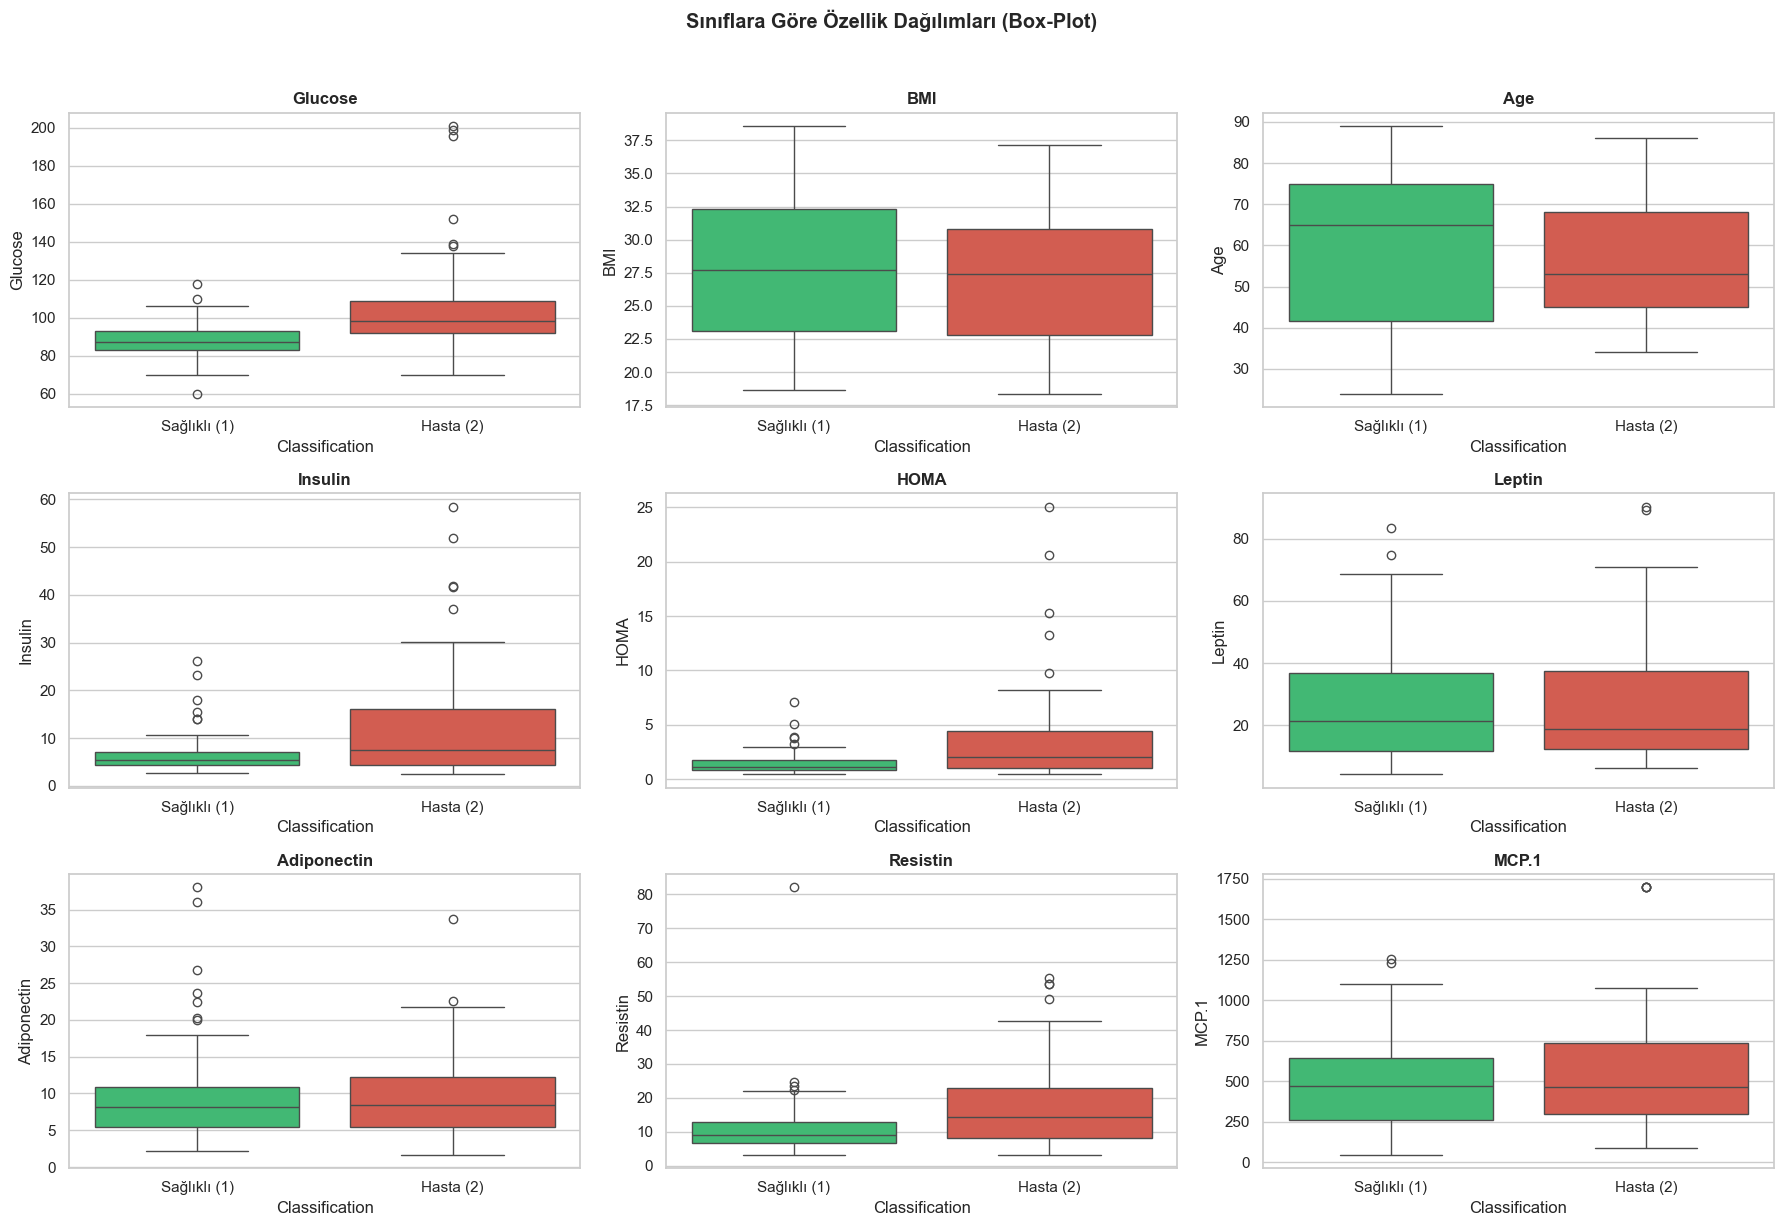

In [20]:
# Box-Plot (Sınıfa Göre)
# özelliklerin hasta ve sağlıklı arasındaki dağılımları
df['Classification'] = df['Classification'].astype(str)

sayisal_ozellikler = ['Glucose', 'BMI', 'Age', 'Insulin', 'HOMA',
                      'Leptin', 'Adiponectin', 'Resistin', 'MCP.1']
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ozellik in enumerate(sayisal_ozellikler):
    sns.boxplot(x='Classification', y=ozellik, data=df,
                palette={'1': '#2ecc71', '2': '#e74c3c'}, ax=axes[i])
    axes[i].set_title(ozellik, fontweight='bold')
    axes[i].set_xticklabels(['Sağlıklı (1)', 'Hasta (2)'])

plt.suptitle("Sınıflara Göre Özellik Dağılımları (Box-Plot)",
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
df = df_raw.copy()   # EDA'daki tip değişimlerinden etkilenmemek için geri dön

In [22]:
print("VERİ HAZIRLAMA VE ÖN İŞLEME")

if len(df) == 0:
    print("\n HATA: Veri setiniz şu an tamamen BOŞ (0 satır).")
    print("ÇÖZÜM: 'Kernel -> Restart & Run All' yaparak en baştan çalıştırın.")
else:
    print("\n Eksik Veri Kontrolü:")
    print(df.isnull().sum().to_string())
    print(f"\nToplam eksik değer: {df.isnull().sum().sum()}")

VERİ HAZIRLAMA VE ÖN İŞLEME

 Eksik Veri Kontrolü:
Age               0
BMI               0
Glucose           0
Insulin           0
HOMA              0
Leptin            0
Adiponectin       0
Resistin          0
MCP.1             0
Classification    0

Toplam eksik değer: 0


In [23]:
# BOŞ DEĞER KONTROLÜ VE TEMİZLEME
print("\nSıfır Değer Kontrolü (sütun bazında):")

biyomedical_sutunlar = ['Glucose', 'BMI', 'Age', 'Insulin', 'HOMA',
                        'Leptin', 'Adiponectin', 'Resistin', 'MCP.1']

print("\nBu sütunlardaki sıfır değerli satırlar (ham veri):")
for sutun in biyomedical_sutunlar:
    sifir = (df[sutun] == 0).sum()
    print(f"  {sutun:<15}: {sifir} adet sıfır değer")




Sıfır Değer Kontrolü (sütun bazında):

Bu sütunlardaki sıfır değerli satırlar (ham veri):
  Glucose        : 0 adet sıfır değer
  BMI            : 0 adet sıfır değer
  Age            : 0 adet sıfır değer
  Insulin        : 0 adet sıfır değer
  HOMA           : 0 adet sıfır değer
  Leptin         : 0 adet sıfır değer
  Adiponectin    : 0 adet sıfır değer
  Resistin       : 0 adet sıfır değer
  MCP.1          : 0 adet sıfır değer


In [24]:
print("\nEncoding Kontrolü:")
kategorik = df.select_dtypes(include=['object', 'category']).columns
if len(kategorik) == 0:
    print(" Kategorik (object/category) sütun BULUNMAMAKTADIR.")
    print(" Bu nedenle Label Encoding veya One-Hot Encoding GEREKMEZ.")
else:
    print(f"\nKategorik sütunlar: {list(kategorik)}")


Encoding Kontrolü:
 Kategorik (object/category) sütun BULUNMAMAKTADIR.
 Bu nedenle Label Encoding veya One-Hot Encoding GEREKMEZ.


In [25]:
# Hedef Dönüştürme: 1→0 (Sağlıklı), 2→1 (Hasta)
df['Classification'] = df['Classification'].astype(int).replace({1: 0, 2: 1})
print("\nHedef Dönüşümü: 1→0 (Sağlıklı), 2→1 (Hasta)")
print(df['Classification'].value_counts().to_string())


Hedef Dönüşümü: 1→0 (Sağlıklı), 2→1 (Hasta)
Classification
1    64
0    52


In [26]:
# Özellik (X) / Hedef (y) Ayrımı
X = df.drop('Classification', axis=1).copy()
y = df['Classification'].copy()
print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (116, 9)
y.shape: (116,)


In [27]:
print(X)

     Age        BMI  Glucose  Insulin      HOMA   Leptin  Adiponectin  \
0     48  23.500000       70    2.707  0.467409   8.8071     9.702400   
1     83  20.690495       92    3.115  0.706897   8.8438     5.429285   
2     82  23.124670       91    4.498  1.009651  17.9393    22.432040   
3     68  21.367521       77    3.226  0.612725   9.8827     7.169560   
4     86  21.111111       92    3.549  0.805386   6.6994     4.819240   
..   ...        ...      ...      ...       ...      ...          ...   
111   45  26.850000       92    3.330  0.755688  54.6800    12.100000   
112   62  26.840000      100    4.530  1.117400  12.4500    21.420000   
113   65  32.050000       97    5.730  1.370998  61.4800    22.540000   
114   72  25.590000       82    2.820  0.570392  24.9600    33.750000   
115   86  27.180000      138   19.910  6.777364  90.2800    14.110000   

     Resistin    MCP.1  
0     7.99585  417.114  
1     4.06405  468.786  
2     9.27715  554.697  
3    12.76600  928.220 

In [28]:
X

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920
...,...,...,...,...,...,...,...,...,...
111,45,26.850000,92,3.330,0.755688,54.6800,12.100000,10.96000,268.230
112,62,26.840000,100,4.530,1.117400,12.4500,21.420000,7.32000,330.160
113,65,32.050000,97,5.730,1.370998,61.4800,22.540000,10.33000,314.050
114,72,25.590000,82,2.820,0.570392,24.9600,33.750000,3.27000,392.460


In [29]:
y

0      0
1      0
2      0
3      0
4      0
      ..
111    1
112    1
113    1
114    1
115    1
Name: Classification, Length: 116, dtype: int64

In [30]:
# Train – Test Bölünmesi  (%80 Eğitim  /  %20 Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"\nTrain-Test Bölünmesi (80/20 - stratified):")
print(f"  Toplam örnek : {len(y)}")
print(f"  Eğitim seti  : {X_train.shape[0]} örnek  (%80)")
print(f"  Test seti    : {X_test.shape[0]} örnek   (%20)")
print(f"\nEğitim → Sağlıklı: {(y_train==0).sum()}, Hasta: {(y_train==1).sum()}")
print(f"  Test   → Sağlıklı: {(y_test==0).sum()},  Hasta: {(y_test==1).sum()}")


Train-Test Bölünmesi (80/20 - stratified):
  Toplam örnek : 116
  Eğitim seti  : 92 örnek  (%80)
  Test seti    : 24 örnek   (%20)

Eğitim → Sağlıklı: 41, Hasta: 51
  Test   → Sağlıklı: 11,  Hasta: 13


In [31]:
# Imputasyon sadece train istatistiğiyle 
print("\nSıfır Değer Kontrolü (TRAIN):")
for sutun in biyomedical_sutunlar:
    sifir = (X_train[sutun] == 0).sum()
    print(f"  {sutun:<15}: {sifir} adet sıfır değer")

X_train[biyomedical_sutunlar] = X_train[biyomedical_sutunlar].replace(0, np.nan)
X_test[biyomedical_sutunlar]  = X_test[biyomedical_sutunlar].replace(0, np.nan)

train_means = X_train[biyomedical_sutunlar].mean()

X_train[biyomedical_sutunlar] = X_train[biyomedical_sutunlar].fillna(train_means)
X_test[biyomedical_sutunlar]  = X_test[biyomedical_sutunlar].fillna(train_means)

print("\nTemizleme sonrası eksik veri:")
print("X_train eksik:", int(X_train.isnull().sum().sum()))
print("X_test  eksik:", int(X_test.isnull().sum().sum()))
print("Veri temizleme tamamlandı")


Sıfır Değer Kontrolü (TRAIN):
  Glucose        : 0 adet sıfır değer
  BMI            : 0 adet sıfır değer
  Age            : 0 adet sıfır değer
  Insulin        : 0 adet sıfır değer
  HOMA           : 0 adet sıfır değer
  Leptin         : 0 adet sıfır değer
  Adiponectin    : 0 adet sıfır değer
  Resistin       : 0 adet sıfır değer
  MCP.1          : 0 adet sıfır değer

Temizleme sonrası eksik veri:
X_train eksik: 0
X_test  eksik: 0
Veri temizleme tamamlandı


In [32]:
# Standardizasyon (Z-Score) 
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)   # Eğitimde fit+transform
X_test_sc  = scaler.transform(X_test)        # Testte sadece transform

print(f"\nStandardizasyon (StandardScaler – Z-Score) UYGULANDI.")
print(f"  X_train boyutu : {X_train_sc.shape}")
print(f"  X_test boyutu  : {X_test_sc.shape}")


Standardizasyon (StandardScaler – Z-Score) UYGULANDI.
  X_train boyutu : (92, 9)
  X_test boyutu  : (24, 9)


In [33]:
# FEATURE SELECTION (ANOVA – SelectKBest, k=5)
ozellik_isimleri = X.columns

# ANOVA F-değerine göre en iyi 5 özelliği seçecek modelin kurulması
selector = SelectKBest(score_func=f_classif, k=5)
X_train_fs = selector.fit_transform(X_train_sc, y_train)
X_test_fs  = selector.transform(X_test_sc)

print("Özellik seçimi başarıyla uygulandı.")

Özellik seçimi başarıyla uygulandı.


In [34]:
secilenler_maskesi = selector.get_support()
secilen_ozellikler = ozellik_isimleri[secilenler_maskesi]
f_scores   = selector.scores_
p_values   = selector.pvalues_

fs_df = pd.DataFrame({
    'Özellik': ozellik_isimleri,
    'F-Skoru': f_scores.round(4),
    'p-Değeri': p_values.round(6),
    'Seçildi': secilenler_maskesi
}).sort_values('F-Skoru', ascending=False)

print(f"\nSeçim öncesi özellik sayısı : {X_train_sc.shape[1]}")
print(f"Seçim sonrası özellik sayısı : {X_train_fs.shape[1]}")


Seçim öncesi özellik sayısı : 9
Seçim sonrası özellik sayısı : 5


In [35]:
print(f"\nTüm Özellikler – F-Skoru ve p-Değeri:\n")
print(fs_df.to_string(index=False))
print(f"\nSeçilen 5 Özellik: {list(secilen_ozellikler)}")


Tüm Özellikler – F-Skoru ve p-Değeri:

    Özellik  F-Skoru  p-Değeri  Seçildi
    Glucose  20.1373  0.000021     True
       HOMA   8.2826  0.004999     True
    Insulin   6.6865  0.011321     True
   Resistin   3.9159  0.050889     True
        BMI   0.9777  0.325416     True
      MCP.1   0.2406  0.625002    False
     Leptin   0.2256  0.635980    False
        Age   0.2184  0.641414    False
Adiponectin   0.0746  0.785367    False

Seçilen 5 Özellik: ['BMI', 'Glucose', 'Insulin', 'HOMA', 'Resistin']


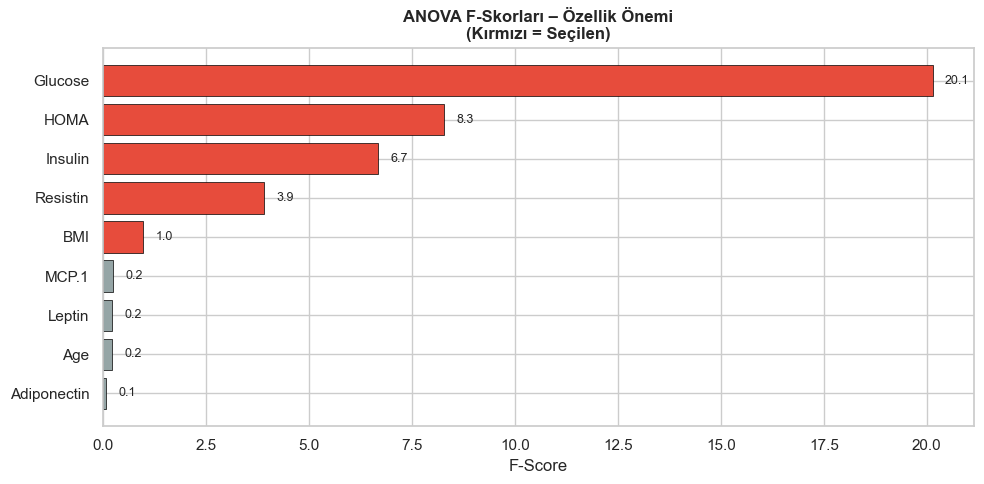

In [36]:
# ANOVA F-Skoru Grafiği

plt.figure(figsize=(10, 5))

# Çubuk grafiği oluşturma (Seçilenler Kırmızı, Diğerleri Gri)
bars = plt.barh(fs_df['Özellik'], fs_df['F-Skoru'],
                color=['#e74c3c' if s else '#95a5a6' for s in fs_df['Seçildi']],
                edgecolor='black', linewidth=0.5)

plt.gca().invert_yaxis() # En yüksek skorun en üstte olması için
plt.title("ANOVA F-Skorları – Özellik Önemi\n(Kırmızı = Seçilen)", fontweight='bold')
plt.xlabel("F-Score")

# Çubukların yanına değerleri yazdırma
for bar, val in zip(bars, fs_df['F-Skoru']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [37]:
# Random Forest 
rf_params = {
    'n_estimators'     : [50, 100, 200, 300],
    'max_depth'        : [None, 3, 4, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
    'criterion'        : ['gini', 'entropy']
}

gs_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                     rf_params, cv=5, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_train_fs, y_train)

best_rf = gs_rf.best_estimator_

print(f"\n[RF] Eğitim Tamamlandı!")
print(f"[RF] En İyi Parametreler  : {gs_rf.best_params_}")
print(f"[RF] CV Accuracy (5-fold) : {gs_rf.best_score_:.4f}")


[RF] Eğitim Tamamlandı!
[RF] En İyi Parametreler  : {'criterion': 'entropy', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
[RF] CV Accuracy (5-fold) : 0.7836


In [38]:
# KNN 
knn_params = {
    'n_neighbors': [11, 15, 21, 25],  # Küçük sayıları eledik!
    'metric'     : ['euclidean', 'manhattan'],
    'weights'    : ['uniform'] # 'distance' yerine 'uniform' kullanmak overfitting'i azaltır
}

gs_knn = GridSearchCV(KNeighborsClassifier(),
                      knn_params, cv=5, scoring='accuracy', n_jobs=-1)
gs_knn.fit(X_train_fs, y_train)
best_knn = gs_knn.best_estimator_ # Yeni, daha "olgun" modelimiz bu oldu.

print(f"\n[KNN] Eğitim Tamamlandı!")
print(f"[KNN] En İyi Parametreler  : {gs_knn.best_params_}")
print(f"[KNN] CV Accuracy (5-fold) : {gs_knn.best_score_:.4f}")


[KNN] Eğitim Tamamlandı!
[KNN] En İyi Parametreler  : {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
[KNN] CV Accuracy (5-fold) : 0.7842


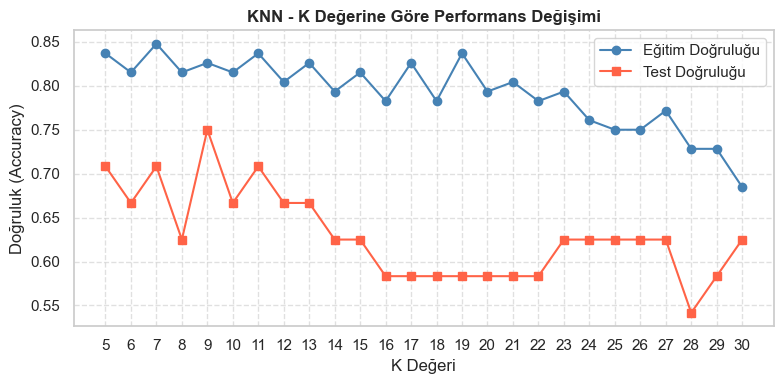

In [39]:
#  KNN K-Değeri Optimizasyon Grafiği
k_aralik = range(5, 31)
train_acc, test_acc = [], []

for k in k_aralik:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_fs, y_train)
    train_acc.append(accuracy_score(y_train, knn_temp.predict(X_train_fs)))
    test_acc.append(accuracy_score(y_test, knn_temp.predict(X_test_fs)))

plt.figure(figsize=(8, 4))
plt.plot(k_aralik, train_acc, marker='o', label='Eğitim Doğruluğu', color='steelblue')
plt.plot(k_aralik, test_acc,  marker='s', label='Test Doğruluğu', color='tomato')
plt.xlabel('K Değeri')
plt.ylabel('Doğruluk (Accuracy)')
plt.title('KNN - K Değerine Göre Performans Değişimi', fontweight='bold')
plt.xticks(k_aralik)
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout(); plt.show()

In [40]:
# Naive Bayes 
nb_params = {
    "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
}

gs_nb = GridSearchCV(GaussianNB(),
                     nb_params,
                     cv=5,
                     scoring='accuracy',
                     n_jobs=-1)

gs_nb.fit(X_train_fs, y_train)
best_nb = gs_nb.best_estimator_

nb_cv = cross_val_score(best_nb, X_train_fs, y_train,
                        cv=5, scoring='accuracy')

print(f"\n[NB] Eğitim Tamamlandı!")
print("[NB] En iyi parametre:", gs_nb.best_params_)
print(f"[NB] CV Accuracy (5-fold) : {nb_cv.mean():.4f} ± {nb_cv.std():.4f}")



[NB] Eğitim Tamamlandı!
[NB] En iyi parametre: {'var_smoothing': 1e-09}
[NB] CV Accuracy (5-fold) : 0.6193 ± 0.0973


In [41]:
# Decision Tree 
print("Decision Tree modeli eğitiliyor...")

dt_params = {
    'max_depth'        : [3, 4, 5, 10, None], # Max depth ile overfitting önleniyor
    'criterion'        : ['gini', 'entropy'], # bölünme ölçütü
    'min_samples_split': [6, 8, 10],          # küçük olursa daha dallı bir ağaç olur
    'min_samples_leaf' : [6, 7, 8]            # yaprakta olması gereken min örnek
}

gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                     dt_params, cv=5, scoring='accuracy', n_jobs=-1)  
gs_dt.fit(X_train_fs, y_train)                                       

best_dt = gs_dt.best_estimator_

print(f"\n[DT] Eğitim Tamamlandı!")
print(f"[DT] En İyi Parametreler  : {gs_dt.best_params_}")
print(f"[DT] CV Accuracy (5-fold) : {gs_dt.best_score_:.4f}")

Decision Tree modeli eğitiliyor...

[DT] Eğitim Tamamlandı!
[DT] En İyi Parametreler  : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 6, 'min_samples_split': 6}
[DT] CV Accuracy (5-fold) : 0.7082


In [42]:

y_test = y_test.astype(int) 

def predict_int(model, X):
    return model.predict(X).astype(int)  

In [43]:
# PERFORMANS DEĞERLENDİRME & KARŞILAŞTIRMA
# Modellerin sözlüğe alınması
modeller = {
    "Random Forest" : best_rf,
    "KNN"           : best_knn,
    "Naive Bayes"   : best_nb,
    "Decision Tree" : best_dt
}

sonuclar = []
for isim, model in modeller.items():
    y_pred = predict_int(model, X_test_fs)
    sonuclar.append({
        "Model"    : isim,
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall"   : recall_score(y_test, y_pred, zero_division=0),
        "F1-Score" : f1_score(y_test, y_pred, zero_division=0)
    })

karsilastirma_df = pd.DataFrame(sonuclar).set_index("Model")

print("\n=== MODEL KARŞILAŞTIRMA TABLOSU ===")
print(karsilastirma_df.round(4).to_string())


=== MODEL KARŞILAŞTIRMA TABLOSU ===
               Accuracy  Precision  Recall  F1-Score
Model                                               
Random Forest    0.7083     0.8000  0.6154    0.6957
KNN              0.6250     0.7000  0.5385    0.6087
Naive Bayes      0.6250     0.8333  0.3846    0.5263
Decision Tree    0.7083     0.8000  0.6154    0.6957


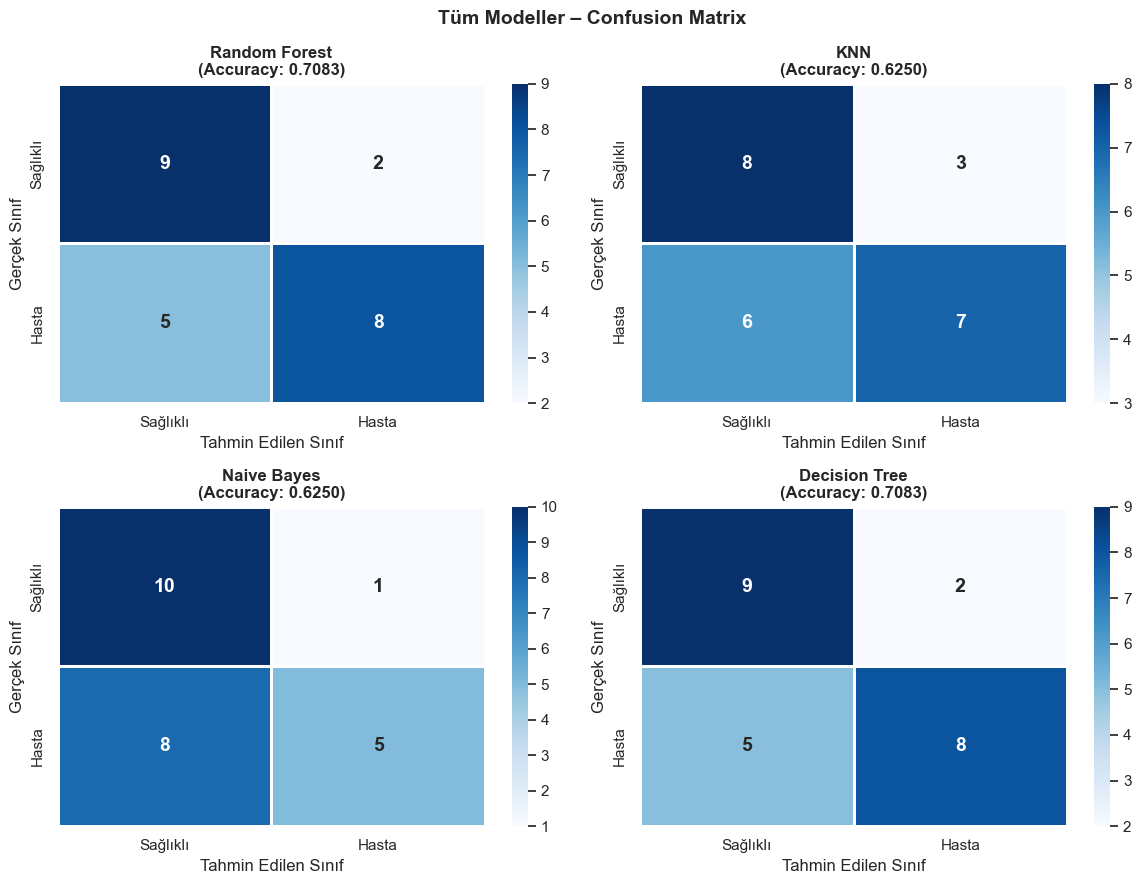

In [44]:
# Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (isim, model) in enumerate(modeller.items()):
    y_pred = predict_int(model, X_test_fs) 
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sağlıklı', 'Hasta'],
                yticklabels=['Sağlıklı', 'Hasta'],
                ax=axes[i], linewidths=1, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    
    acc = accuracy_score(y_test, y_pred)
    axes[i].set_title(f"{isim}\n(Accuracy: {acc:.4f})", fontweight='bold')
    axes[i].set_xlabel("Tahmin Edilen Sınıf")
    axes[i].set_ylabel("Gerçek Sınıf")

plt.suptitle("Tüm Modeller – Confusion Matrix", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

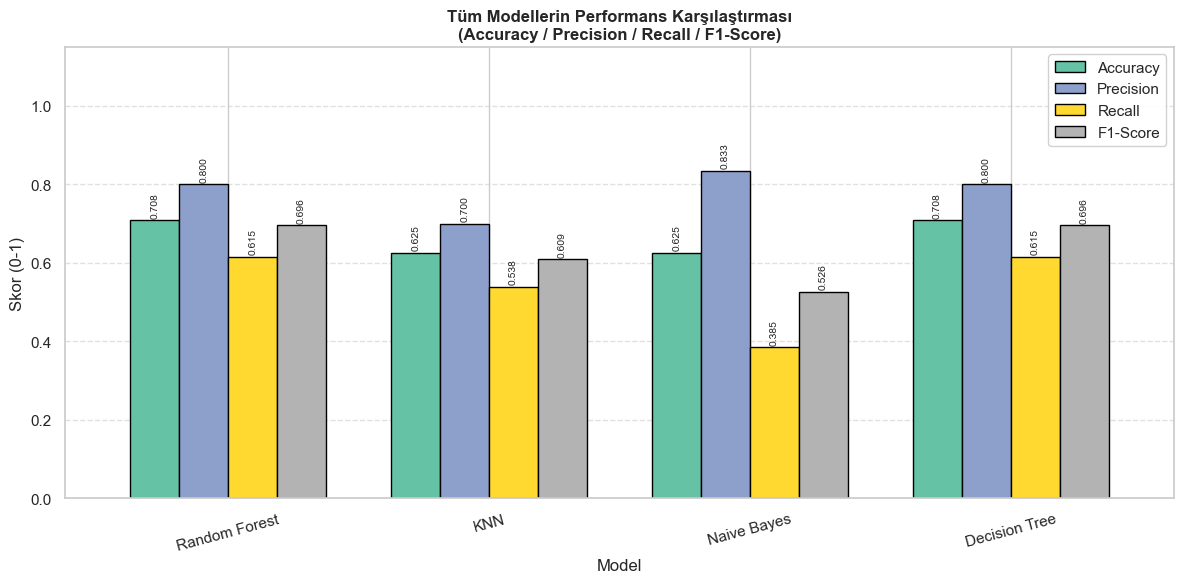

In [45]:
# Görsel Karşılaştırma Bar Chart
karsilastirma_df.plot(kind='bar', figsize=(12, 6), 
                      ylim=(0.0, 1.15),  
                      colormap='Set2', edgecolor='black', width=0.75)

plt.title("Tüm Modellerin Performans Karşılaştırması\n(Accuracy / Precision / Recall / F1-Score)",
          fontweight='bold')
plt.ylabel("Skor (0-1)")
plt.xticks(rotation=15)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', fontsize=7.5,
                        padding=2, rotation=90)

plt.tight_layout()
plt.show()

In [46]:
# Overfitting Kontrolü

print(" OVERFİTTİNG KONTROLÜ")
print(f"\n{'Model':<20} {'Train Acc':>10} {'Test Acc':>10} {'CV Acc':>10}  {'Yorum'}")

# CV skorları
cv_scores = {
    "Random Forest": gs_rf.best_score_,
    "KNN"          : gs_knn.best_score_,
    "Naive Bayes"  : nb_cv.mean(),
    "Decision Tree": gs_dt.best_score_
}

# Modellerin tahminlerini int yaparak kullandık
for isim, model in modeller.items():
    y_pred_train = model.predict(X_train_fs).astype(int)
    y_pred_test  = model.predict(X_test_fs).astype(int)
    
    tr   = accuracy_score(y_train, y_pred_train)
    te   = accuracy_score(y_test,  y_pred_test)
    cv   = cv_scores[isim]
    fark = tr - te
    yorum = "✓ İyi Genelleme" if fark < 0.08 else "⚠ Hafif Overfit"
    
    print(f"{isim:<20} {tr:>10.4f} {te:>10.4f} {cv:>10.4f}  {yorum}")

 OVERFİTTİNG KONTROLÜ

Model                 Train Acc   Test Acc     CV Acc  Yorum
Random Forest            0.9239     0.7083     0.7836  ⚠ Hafif Overfit
KNN                      0.8152     0.6250     0.7842  ⚠ Hafif Overfit
Naive Bayes              0.6304     0.6250     0.6193  ✓ İyi Genelleme
Decision Tree            0.8478     0.7083     0.7082  ⚠ Hafif Overfit


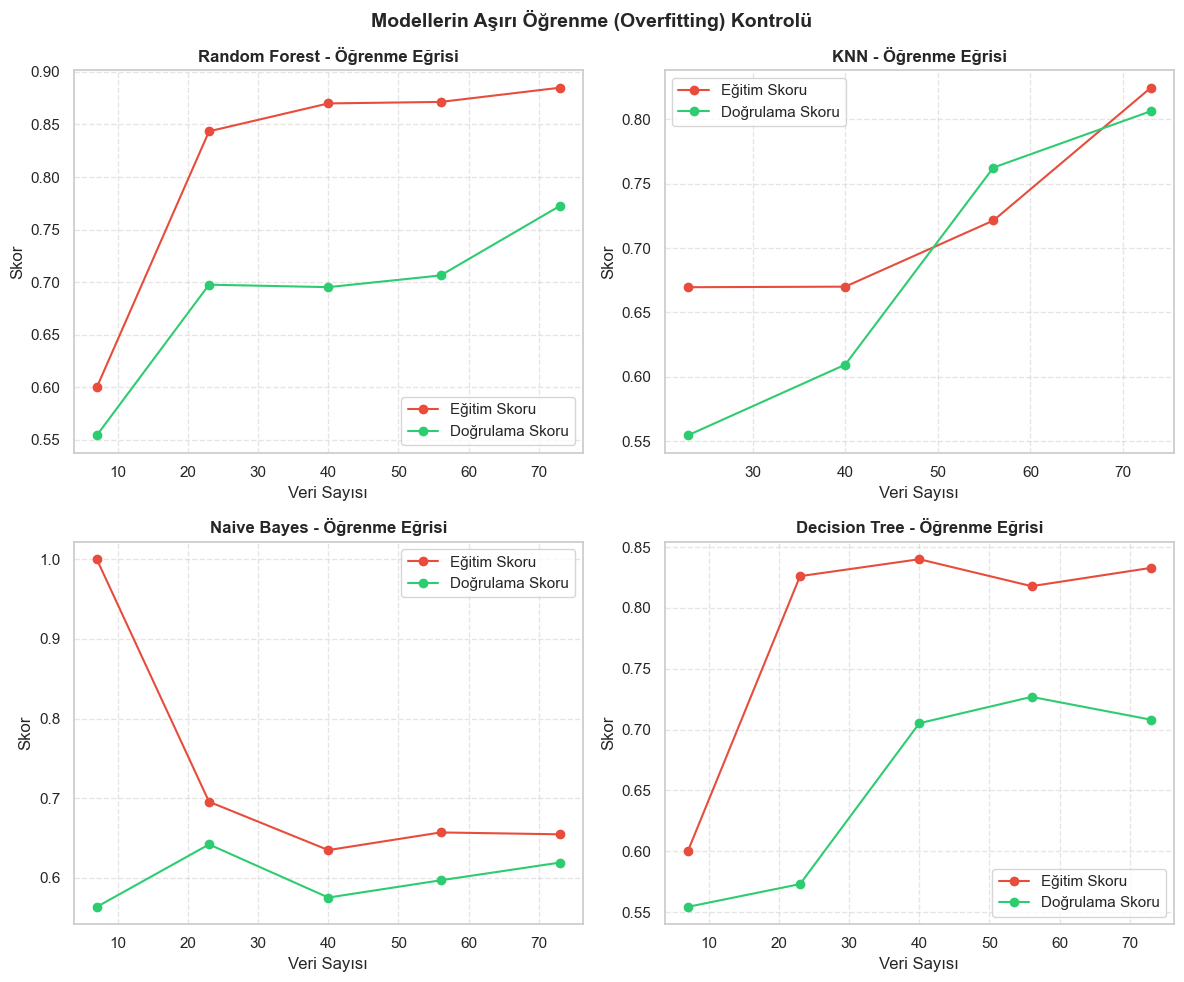

In [47]:
# OVERFITTING KONTROLÜ İÇİN LEARNING CURVE

def plot_learning_curve(estimator, title, ax):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_train_fs, y_train, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy')
    
    ax.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="#e74c3c", label="Eğitim Skoru")
    ax.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color="#2ecc71", label="Doğrulama Skoru")
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Veri Sayısı"); ax.set_ylabel("Skor")
    ax.legend(loc="best"); ax.grid(True, linestyle='--', alpha=0.5)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_learning_curve(best_rf, "Random Forest - Öğrenme Eğrisi", axes[0,0])
plot_learning_curve(best_knn, "KNN - Öğrenme Eğrisi", axes[0,1])
plot_learning_curve(best_nb, "Naive Bayes - Öğrenme Eğrisi", axes[1,0])
plot_learning_curve(best_dt, "Decision Tree - Öğrenme Eğrisi", axes[1,1])
plt.suptitle("Modellerin Aşırı Öğrenme (Overfitting) Kontrolü", fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

In [48]:
# Detaylı Classification Report 
y_test_int = y_test.astype(int)

for isim, model in modeller.items():
    y_pred = model.predict(X_test_fs).astype(int)

    report_dict = classification_report(
        y_test_int,
        y_pred,
        target_names=["Sağlıklı (0)", "Hasta (1)"],
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).T

    print(f"\n{'='*60}")
    print(f"{isim} – Classification Report")
    print(f"{'='*60}")
    print(report_df.round(3))


Random Forest – Classification Report
              precision  recall  f1-score  support
Sağlıklı (0)      0.643   0.818     0.720   11.000
Hasta (1)         0.800   0.615     0.696   13.000
accuracy          0.708   0.708     0.708    0.708
macro avg         0.721   0.717     0.708   24.000
weighted avg      0.728   0.708     0.707   24.000

KNN – Classification Report
              precision  recall  f1-score  support
Sağlıklı (0)      0.571   0.727     0.640   11.000
Hasta (1)         0.700   0.538     0.609   13.000
accuracy          0.625   0.625     0.625    0.625
macro avg         0.636   0.633     0.624   24.000
weighted avg      0.641   0.625     0.623   24.000

Naive Bayes – Classification Report
              precision  recall  f1-score  support
Sağlıklı (0)      0.556   0.909     0.690   11.000
Hasta (1)         0.833   0.385     0.526   13.000
accuracy          0.625   0.625     0.625    0.625
macro avg         0.694   0.647     0.608   24.000
weighted avg      0.706   0.

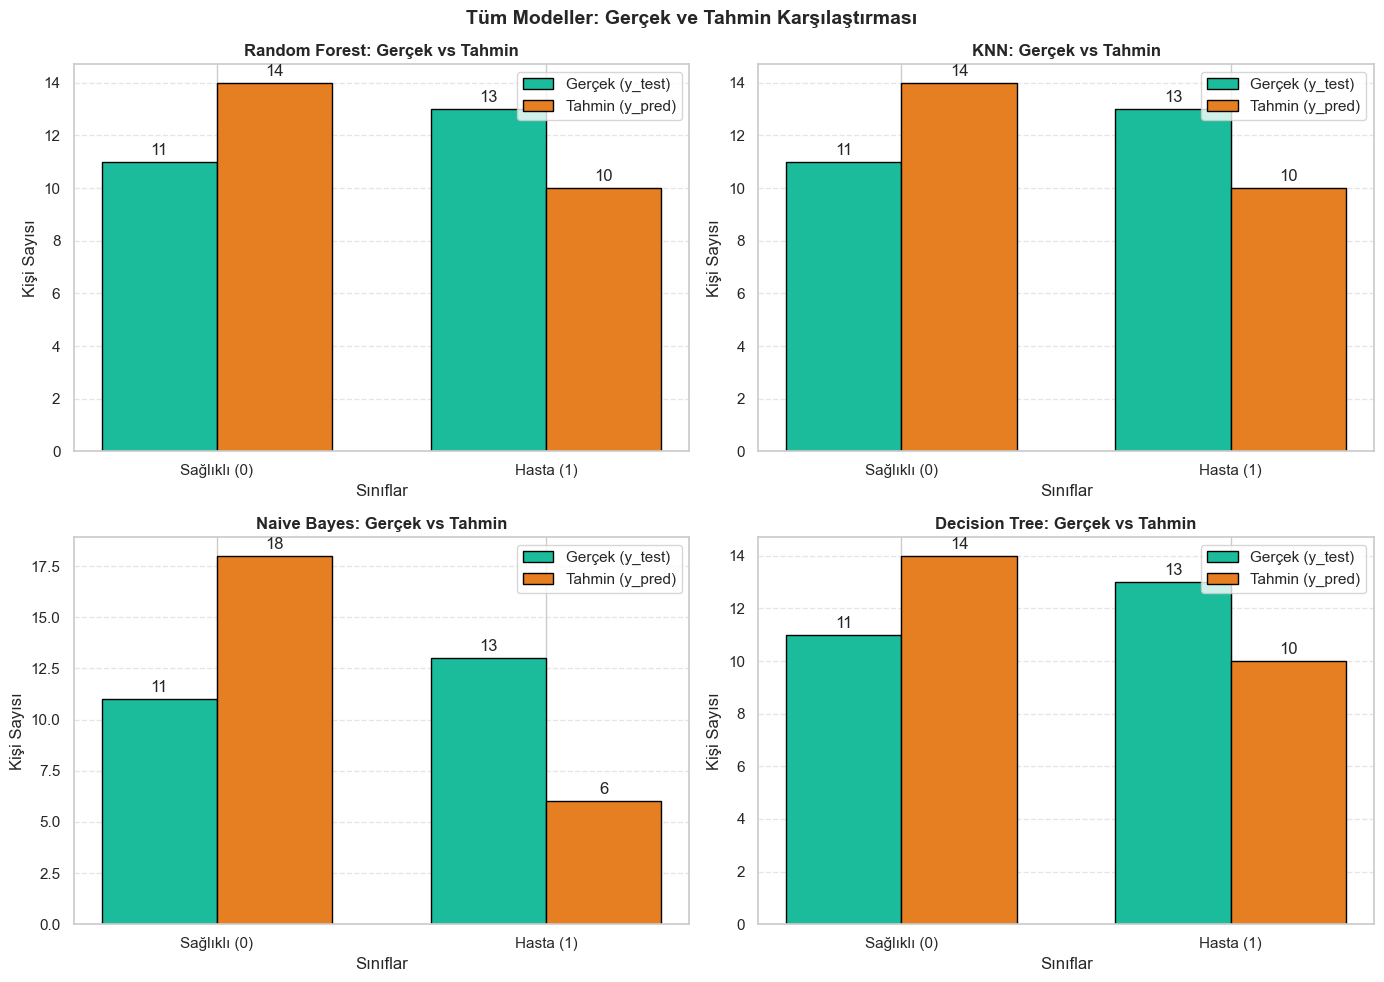

In [49]:
# Gerçek vs Tahmin Bar Grafiği
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Dönüşüm sonrası: 0=Sağlıklı, 1=Hasta
classes  = ["Sağlıklı (0)", "Hasta (1)"]
x_ekseni = np.arange(len(classes))
genislik = 0.35

y_test_int = y_test.astype(int)

gercek_sayilar = [(y_test_int == 0).sum(), (y_test_int == 1).sum()]

for i, (isim, model) in enumerate(modeller.items()):
    y_pred = model.predict(X_test_fs).astype(int)
    
    tahmin_sayilar = [(y_pred == 0).sum(), (y_pred == 1).sum()]
    
    b1 = axes[i].bar(x_ekseni - genislik/2, gercek_sayilar,
                     genislik, label="Gerçek (y_test)",
                     color='#1abc9c', edgecolor='black')
    b2 = axes[i].bar(x_ekseni + genislik/2, tahmin_sayilar,
                     genislik, label="Tahmin (y_pred)",
                     color='#e67e22', edgecolor='black')
    
    axes[i].bar_label(b1, padding=3)
    axes[i].bar_label(b2, padding=3)
    axes[i].set_title(f"{isim}: Gerçek vs Tahmin", fontweight='bold')
    axes[i].set_xlabel("Sınıflar")
    axes[i].set_ylabel("Kişi Sayısı")
    axes[i].set_xticks(x_ekseni)
    axes[i].set_xticklabels(classes)
    axes[i].legend()
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Tüm Modeller: Gerçek ve Tahmin Karşılaştırması",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

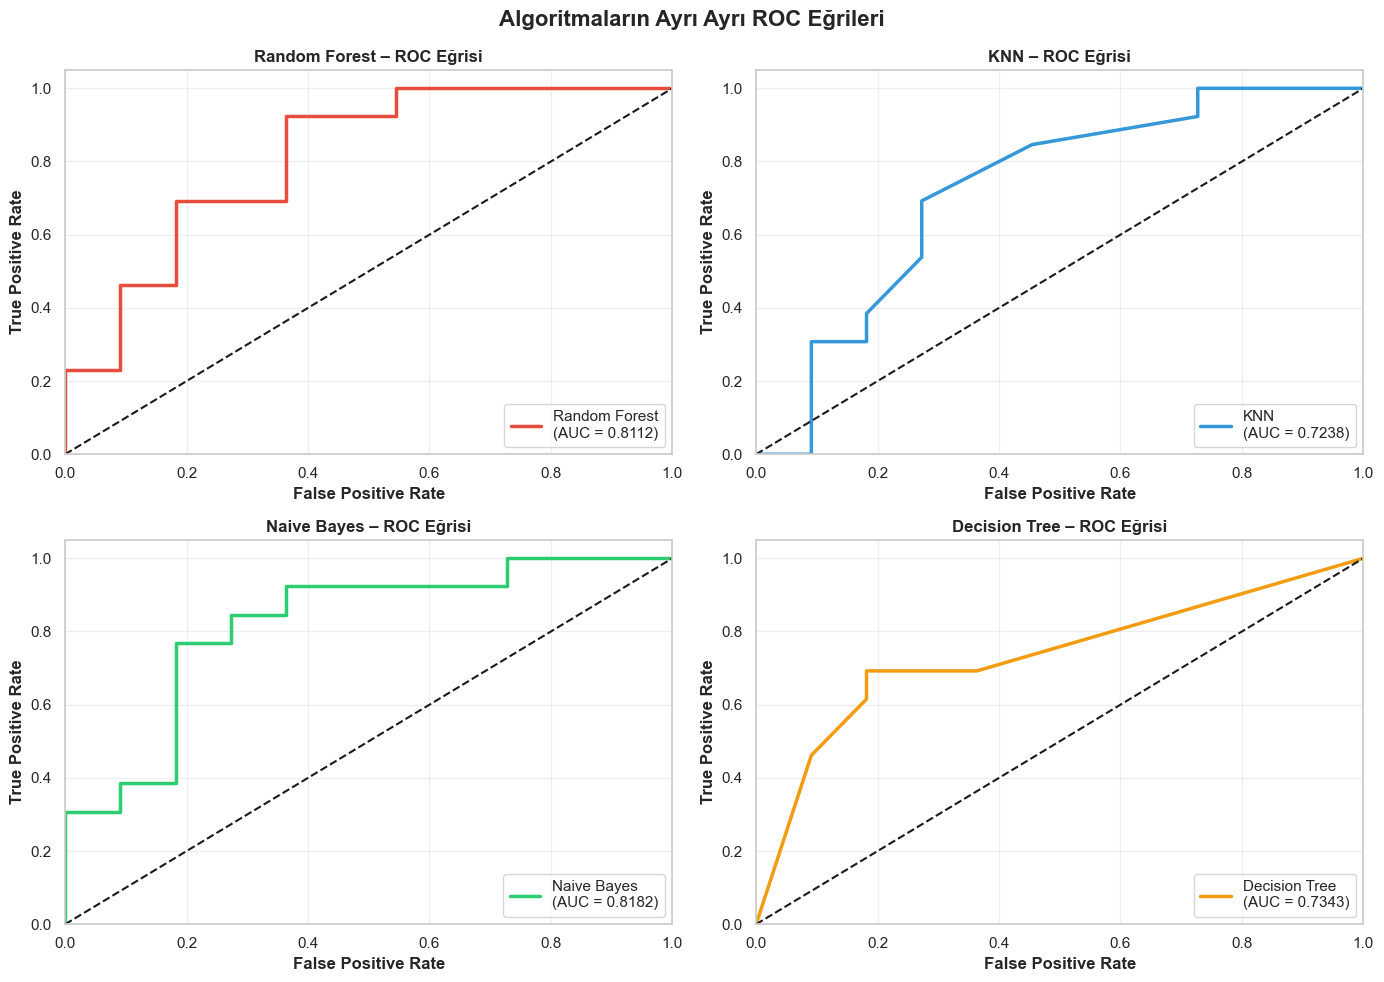

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() 

renkler_roc = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, ((isim, model), renk) in enumerate(zip(modeller.items(), renkler_roc)):
    y_prob = model.predict_proba(X_test_fs)[:, 1]
    fpr, tpr, _ = roc_curve(y_test.astype(int), y_prob, pos_label=1)
    roc_auc = auc(fpr, tpr)
    
    axes[i].plot(fpr, tpr, color=renk, lw=2.5,
                 label=f'{isim}\n(AUC = {roc_auc:.4f})')
    axes[i].plot([0,1],[0,1],'k--',lw=1.5)
    axes[i].set_xlim([0,1]); axes[i].set_ylim([0,1.05])
    axes[i].set_xlabel('False Positive Rate', fontweight='bold')
    axes[i].set_ylabel('True Positive Rate', fontweight='bold')
    axes[i].set_title(f'{isim} – ROC Eğrisi', fontweight='bold')
    axes[i].legend(loc='lower right')
    axes[i].grid(True, alpha=0.3)

# Ana başlık ve boşluk ayarları
plt.suptitle("Algoritmaların Ayrı Ayrı ROC Eğrileri", fontweight='bold', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

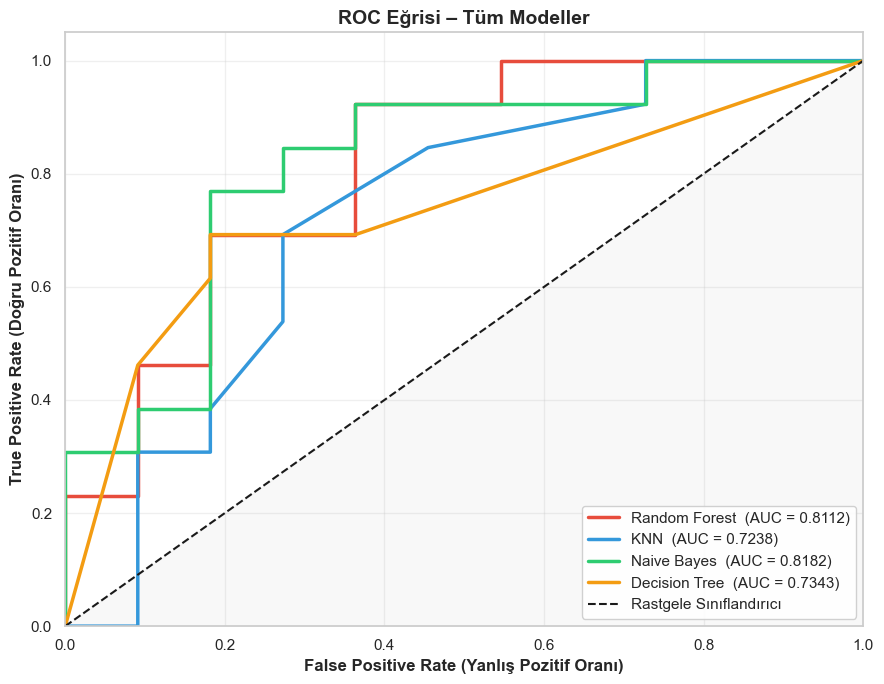

In [51]:
plt.figure(figsize=(9, 7))
renkler_roc = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for (isim, model), renk in zip(modeller.items(), renkler_roc):
    y_prob = model.predict_proba(X_test_fs)[:, 1]  # ← model kullan
    fpr, tpr, _ = roc_curve(y_test.astype(int), y_prob, pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=renk, lw=2.5,
             label=f'{isim}  (AUC = {roc_auc:.4f})')

# Referans Rastgele Sınıflandırıcı çizgisi
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Rastgele Sınıflandırıcı')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)', fontweight='bold')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)', fontweight='bold')
plt.title('ROC Eğrisi – Tüm Modeller', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


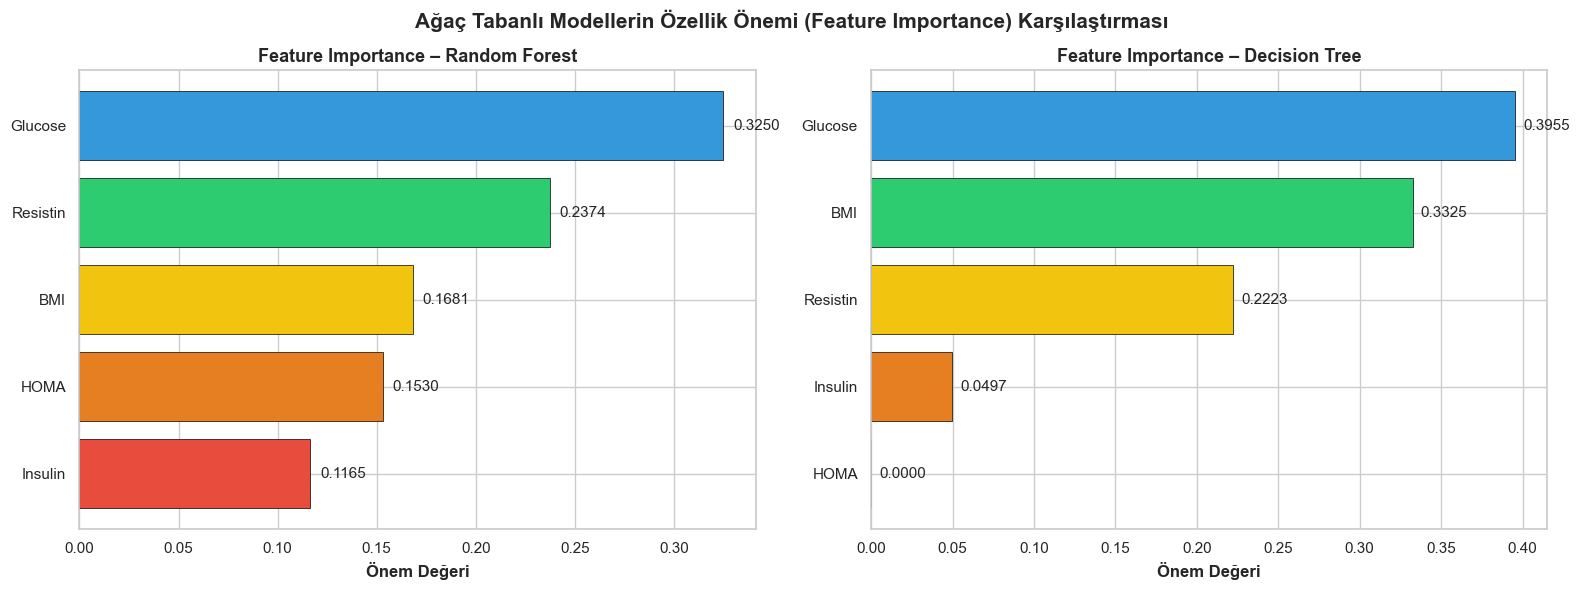

In [52]:
# Feature Importance (Ağaç Tabanlı Modeller İçin)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

agac_modelleri = {
    "Random Forest": best_rf,
    "Decision Tree": best_dt
}

renkler_bar = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']

for i, (isim, model) in enumerate(agac_modelleri.items()):
    # Modelin özellik önemlerini alıyoruz
    importances = model.feature_importances_
    
    # DataFrame oluşturup küçükten büyüğe sıralıyoruz (barh'de en büyük üstte görünsün diye)
    feat_imp = pd.DataFrame({
        'Feature': secilen_ozellikler,
        'Importance': importances
    }).sort_values('Importance', ascending=True)
    
    # Çubuk grafiğini çizdiriyoruz
    bars = axes[i].barh(feat_imp['Feature'], feat_imp['Importance'], 
                        color=renkler_bar, edgecolor='black', linewidth=0.5)
    
    # Başlık ve eksen ayarları
    axes[i].set_title(f"Feature Importance – {isim}", fontweight='bold', fontsize=13)
    axes[i].set_xlabel("Önem Değeri", fontweight='bold')
    
    # Çubukların yanına değerleri yazdırıyoruz
    for bar in bars:
        val = bar.get_width()
        axes[i].text(val + 0.005, bar.get_y() + bar.get_height()/2, 
                     f'{val:.4f}', va='center', fontsize=11)

plt.suptitle("Ağaç Tabanlı Modellerin Özellik Önemi (Feature Importance) Karşılaştırması", 
             fontweight='bold', fontsize=15)
plt.tight_layout()
plt.subplots_adjust(top=0.88) # Ana başlık için biraz boşluk bırakır
plt.show()

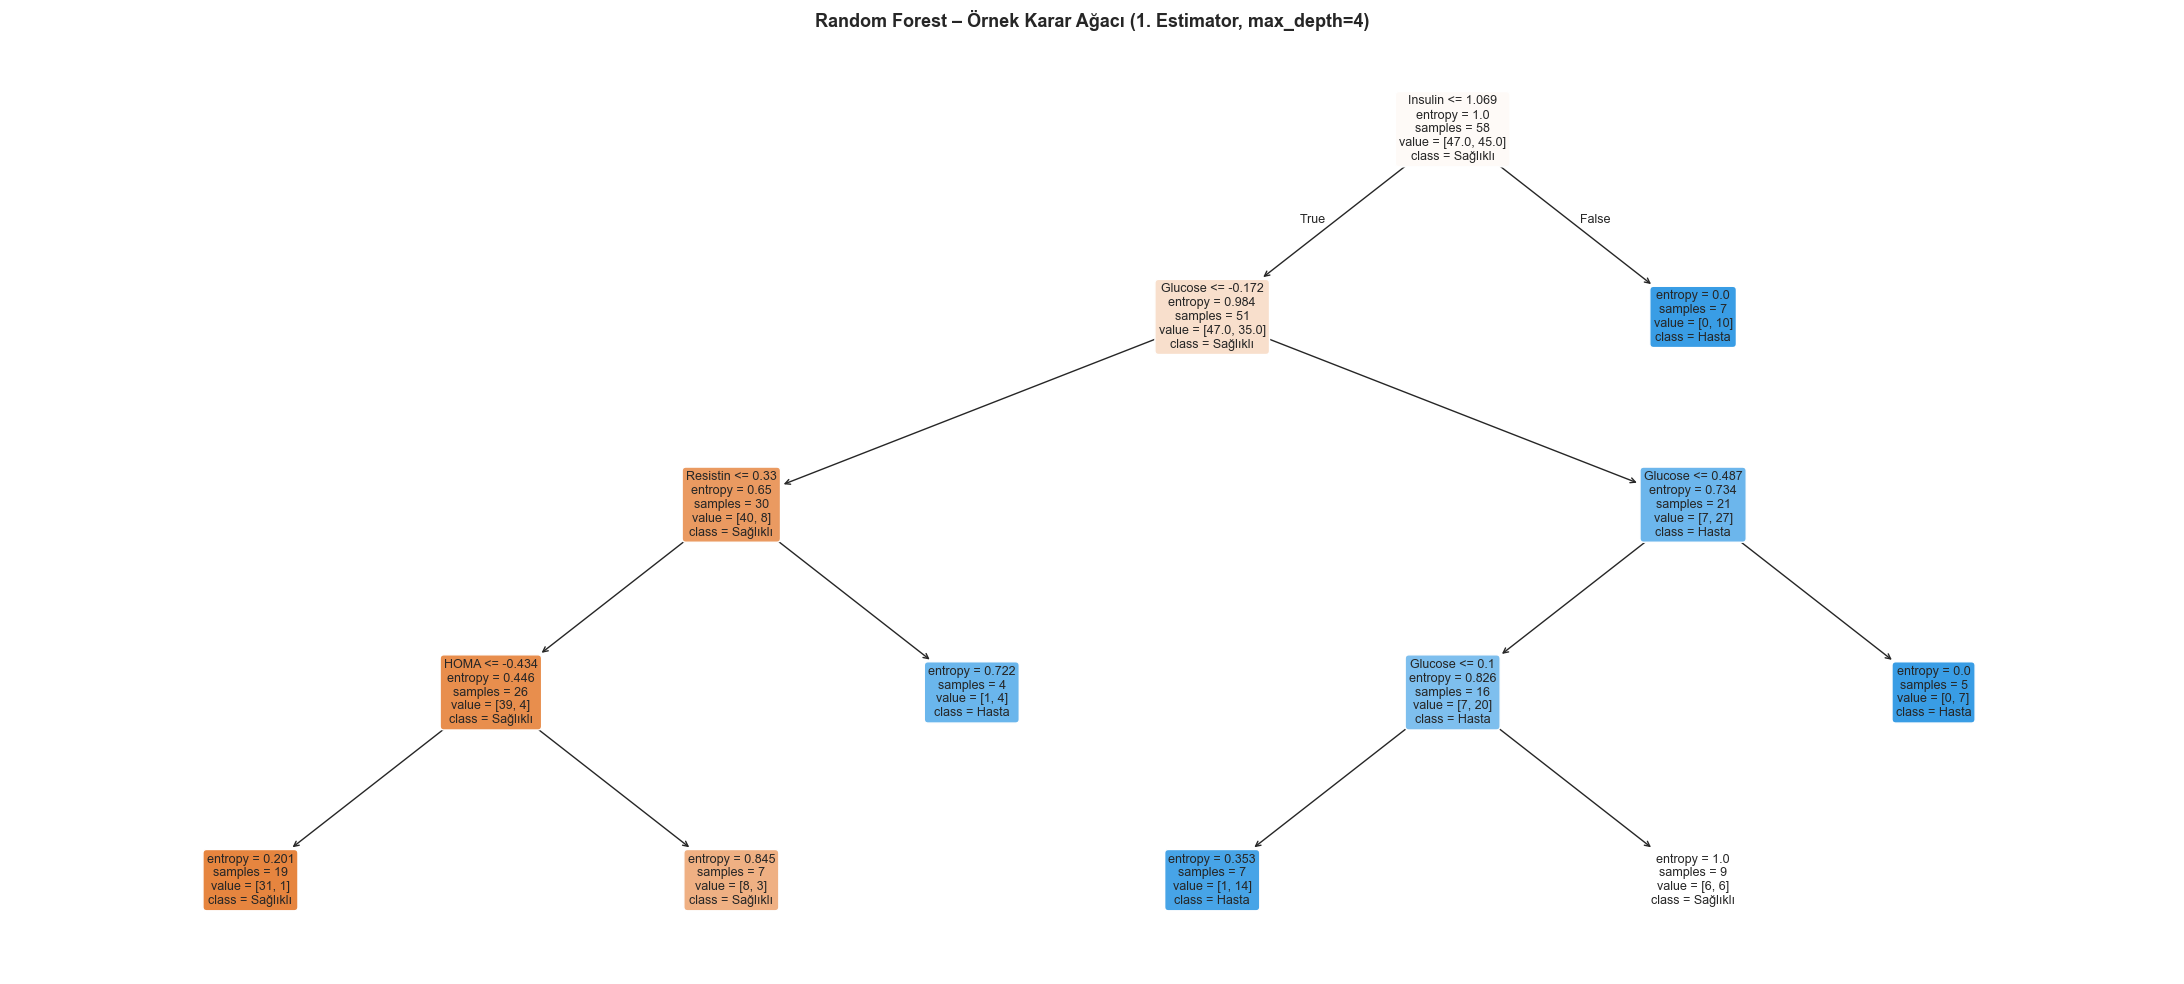

In [53]:
# Karar Ağacı Görselleştirmeleri 
# Random Forest – 1. Tahmin Edici (Estimator)
plt.figure(figsize=(22, 10))
tree.plot_tree(best_rf.estimators_[0],
               feature_names=list(secilen_ozellikler),
               class_names=["Sağlıklı", "Hasta"],
               filled=True, max_depth=4, rounded=True,
               impurity=True, proportion=False, fontsize=9)
plt.title("Random Forest – Örnek Karar Ağacı (1. Estimator, max_depth=4)",
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

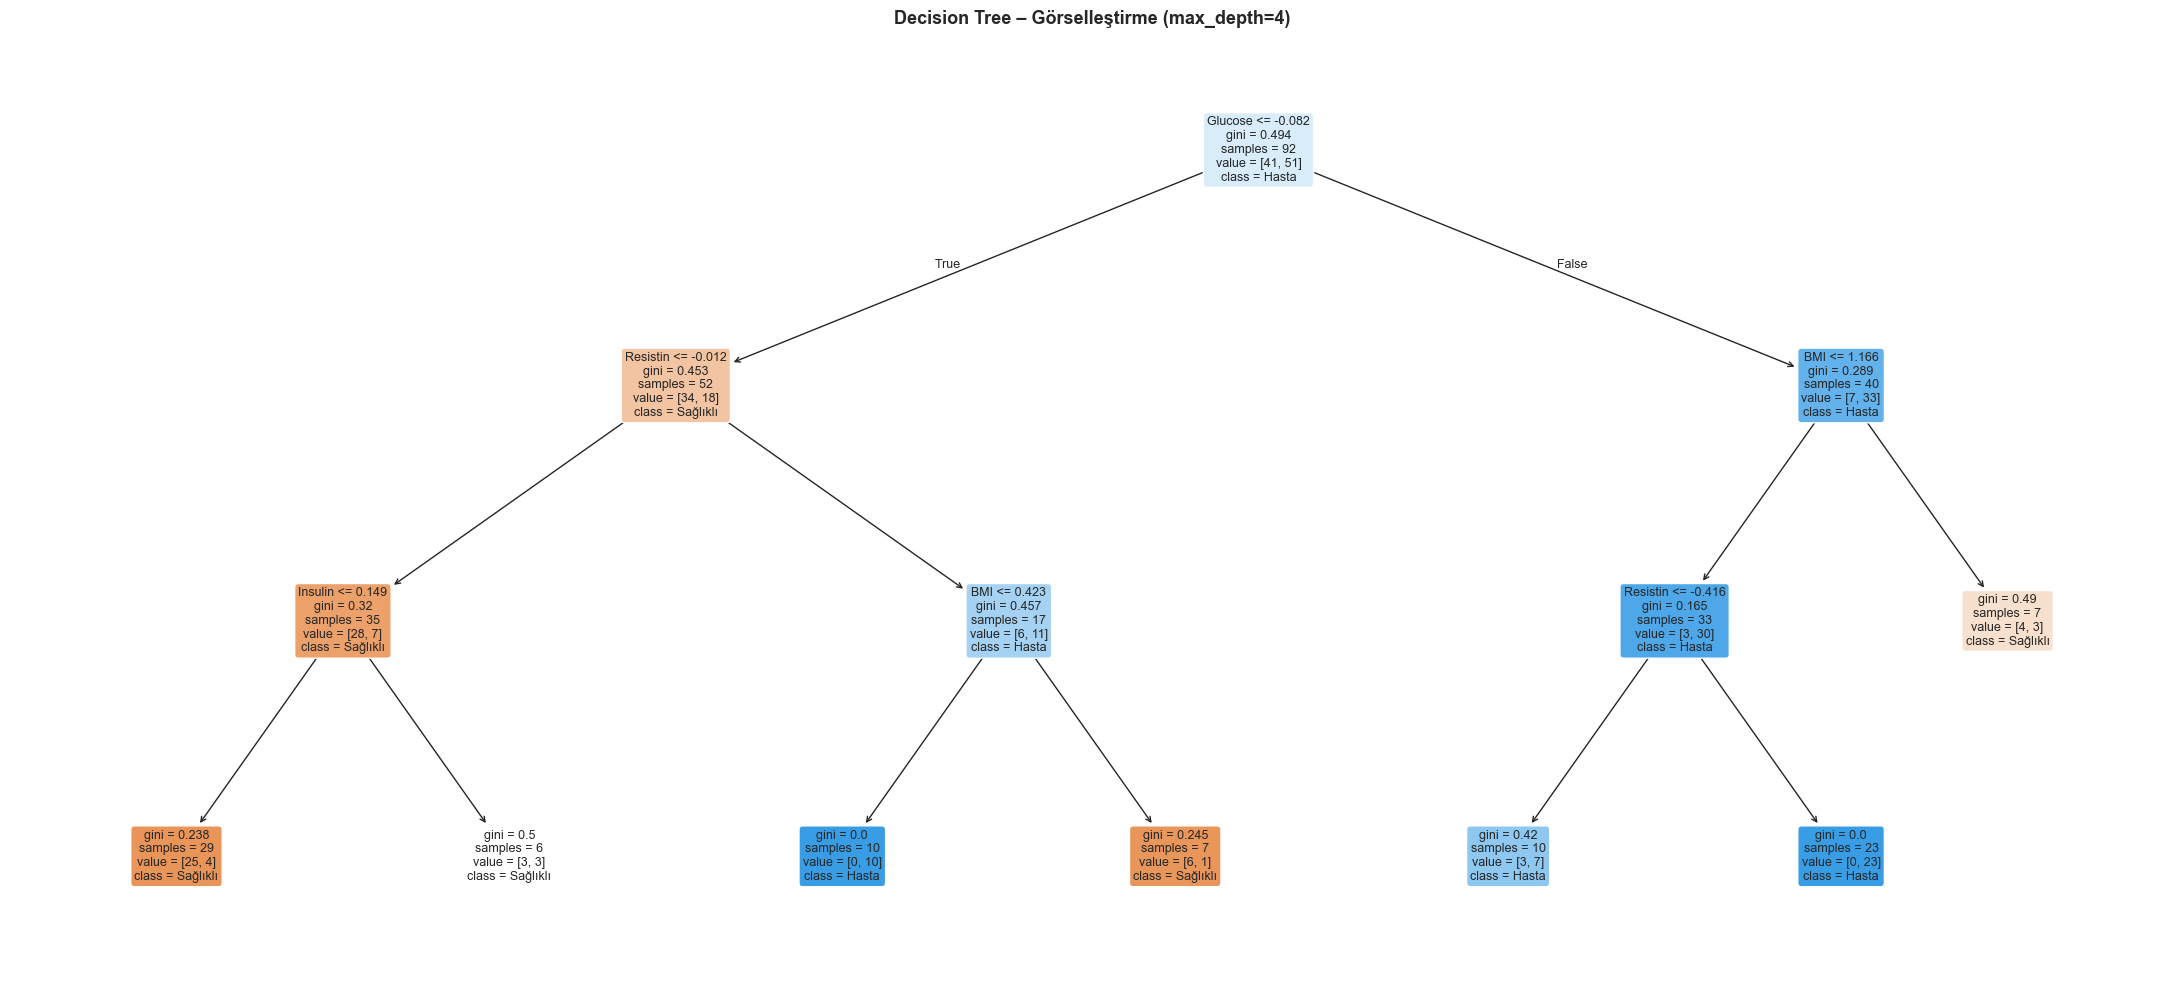

In [54]:
# Decision Tree – En İyi Model
plt.figure(figsize=(22, 10))
tree.plot_tree(best_dt,
               feature_names=list(secilen_ozellikler),
               class_names=["Sağlıklı", "Hasta"],
               filled=True, max_depth=4, rounded=True,
               impurity=True, proportion=False, fontsize=9)
plt.title("Decision Tree – Görselleştirme (max_depth=4)",
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

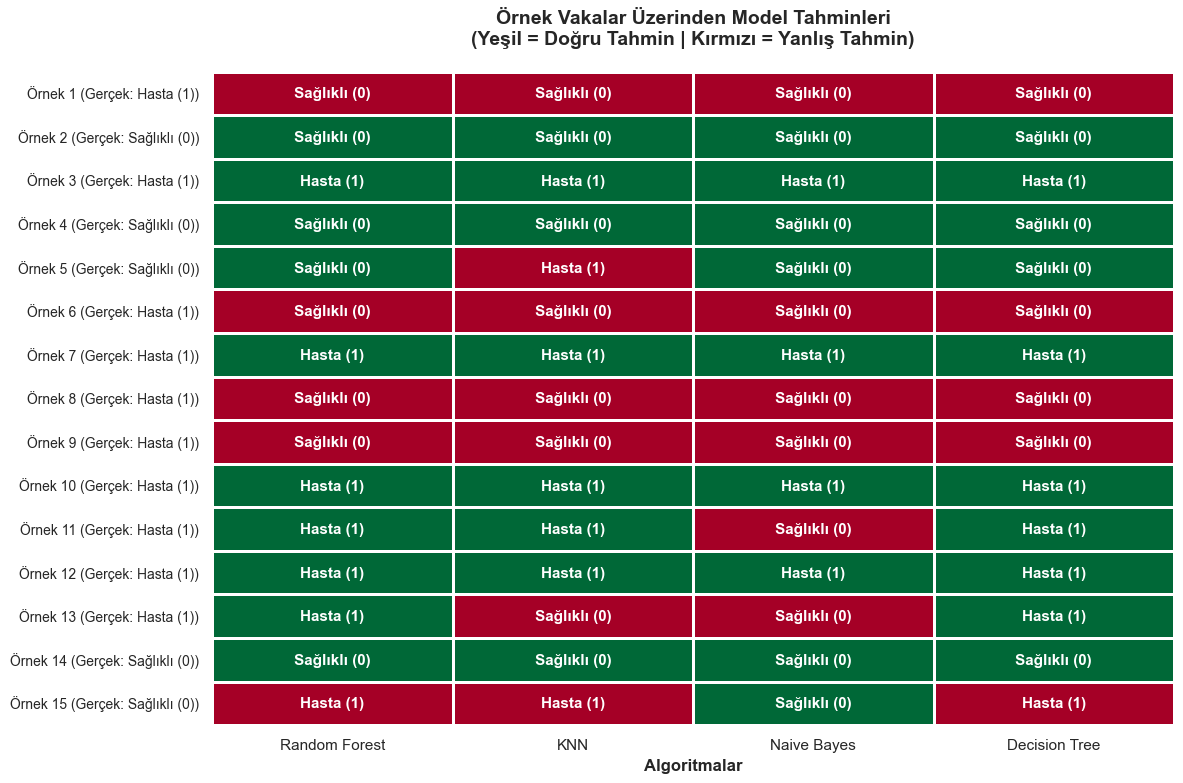

In [55]:
# Örnek Veriler Üzerinden Model Karşılaştırması

# Test setinden ilk 15 örneği alalım
n_samples = 15
X_sample = X_test_fs[:n_samples]
y_actual = y_test[:n_samples].astype(int).values  

# Tahminleri toplayacağımız bir sözlük
karsilastirma_dict = {"Gerçek Değer": y_actual}

for isim, model in modeller.items():
    karsilastirma_dict[isim] = model.predict(X_sample).astype(int)

# DataFrame oluşturma
sample_df = pd.DataFrame(karsilastirma_dict)

# Görselleştirme için sayısal değerleri isimlendirelim
# Doğru eşleme için int ile karşılaştırıyoruz
map_func = lambda x: "Hasta (1)" if x == 1 else "Sağlıklı (0)"
display_df = sample_df.applymap(map_func)

# Renklendirme mantığı: Doğru tahminler yeşil, yanlışlar kırmızı
plt.figure(figsize=(12, 8))

# Sadece doğru/yanlış kontrolü için bir maske oluşturuyoruz
maske = sample_df.copy()
for sutun in modeller.keys():
    maske[sutun] = (sample_df[sutun] == sample_df["Gerçek Değer"])

# Isı haritası çizimi (Doğrular 1, Yanlışlar 0 gibi davranır)
sns.heatmap(maske.iloc[:, 1:].astype(int), annot=display_df.iloc[:, 1:], 
            fmt="", cmap="RdYlGn", cbar=False, linewidths=2, linecolor='white',
            annot_kws={"size": 11, "weight": "bold"})

# Gerçek değerleri sol eksene ekleyelim
plt.yticks(ticks=np.arange(n_samples)+0.5, 
           labels=[f"Örnek {i+1} (Gerçek: {map_func(y_actual[i])})" for i in range(n_samples)], 
           rotation=0, fontsize=10)

plt.title("Örnek Vakalar Üzerinden Model Tahminleri\n(Yeşil = Doğru Tahmin | Kırmızı = Yanlış Tahmin)", 
          fontweight='bold', fontsize=14, pad=20)
plt.xlabel("Algoritmalar", fontweight='bold')
plt.tight_layout()
plt.show()

In [56]:
en_iyi = karsilastirma_df['F1-Score'].idxmax()
en_iyi_row = karsilastirma_df.loc[en_iyi]

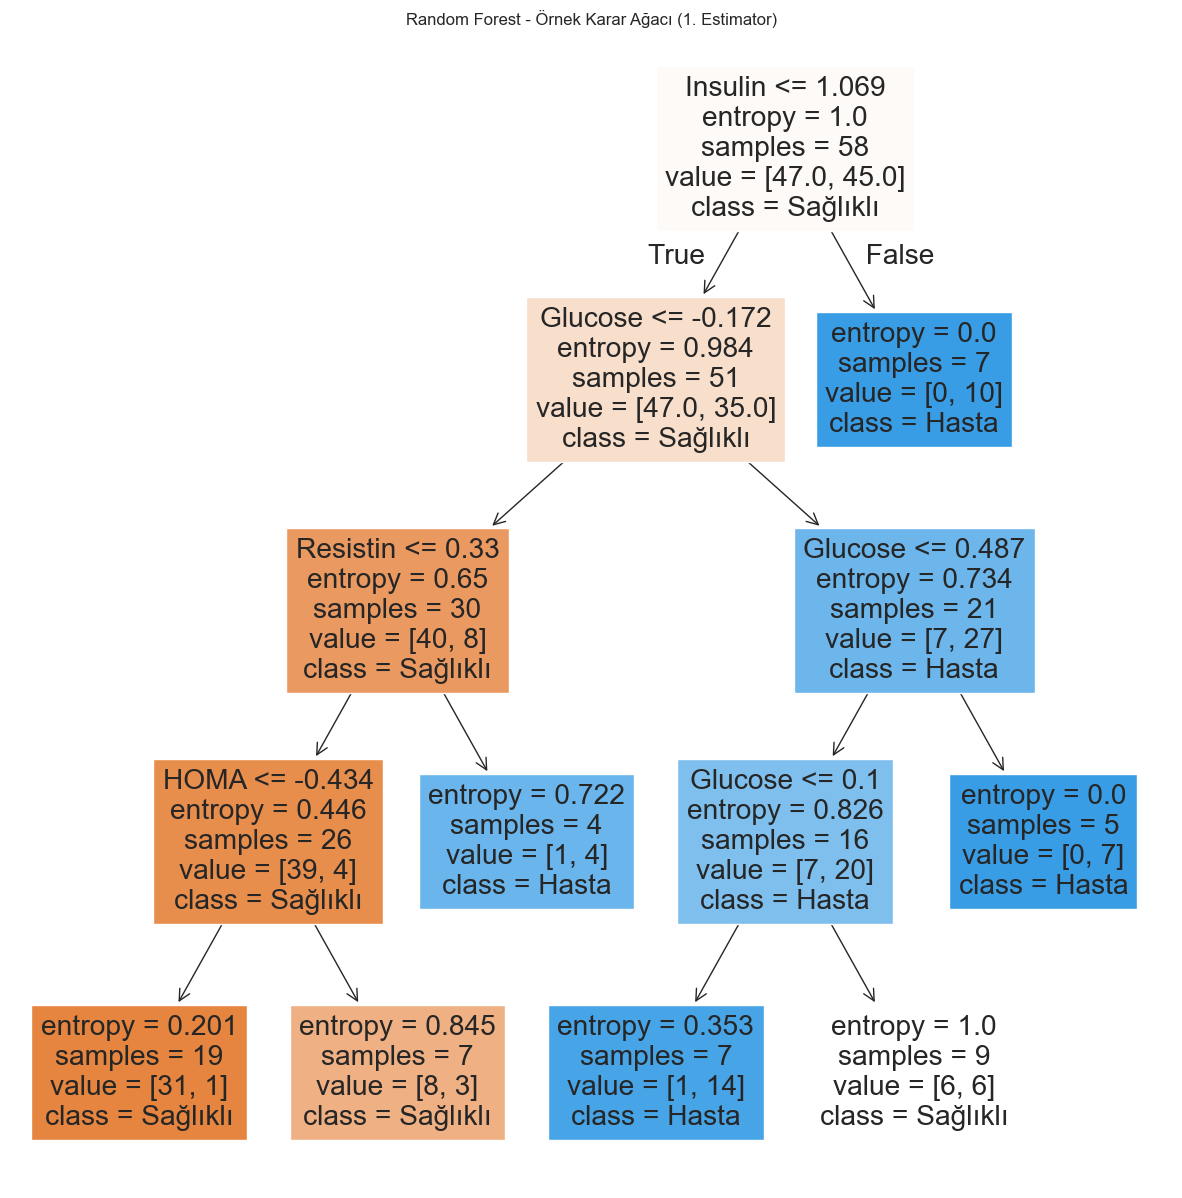

In [57]:
# Karar Ağacı Görselleştirme 
# Random Forest içinden örnek ağaç
plt.figure(figsize=(15, 15))
tree.plot_tree(best_rf.estimators_[0],
               feature_names=secilen_ozellikler,
               class_names=["Sağlıklı", "Hasta"],
               filled=True, max_depth=5)
plt.title("Random Forest - Örnek Karar Ağacı (1. Estimator)")
plt.show()

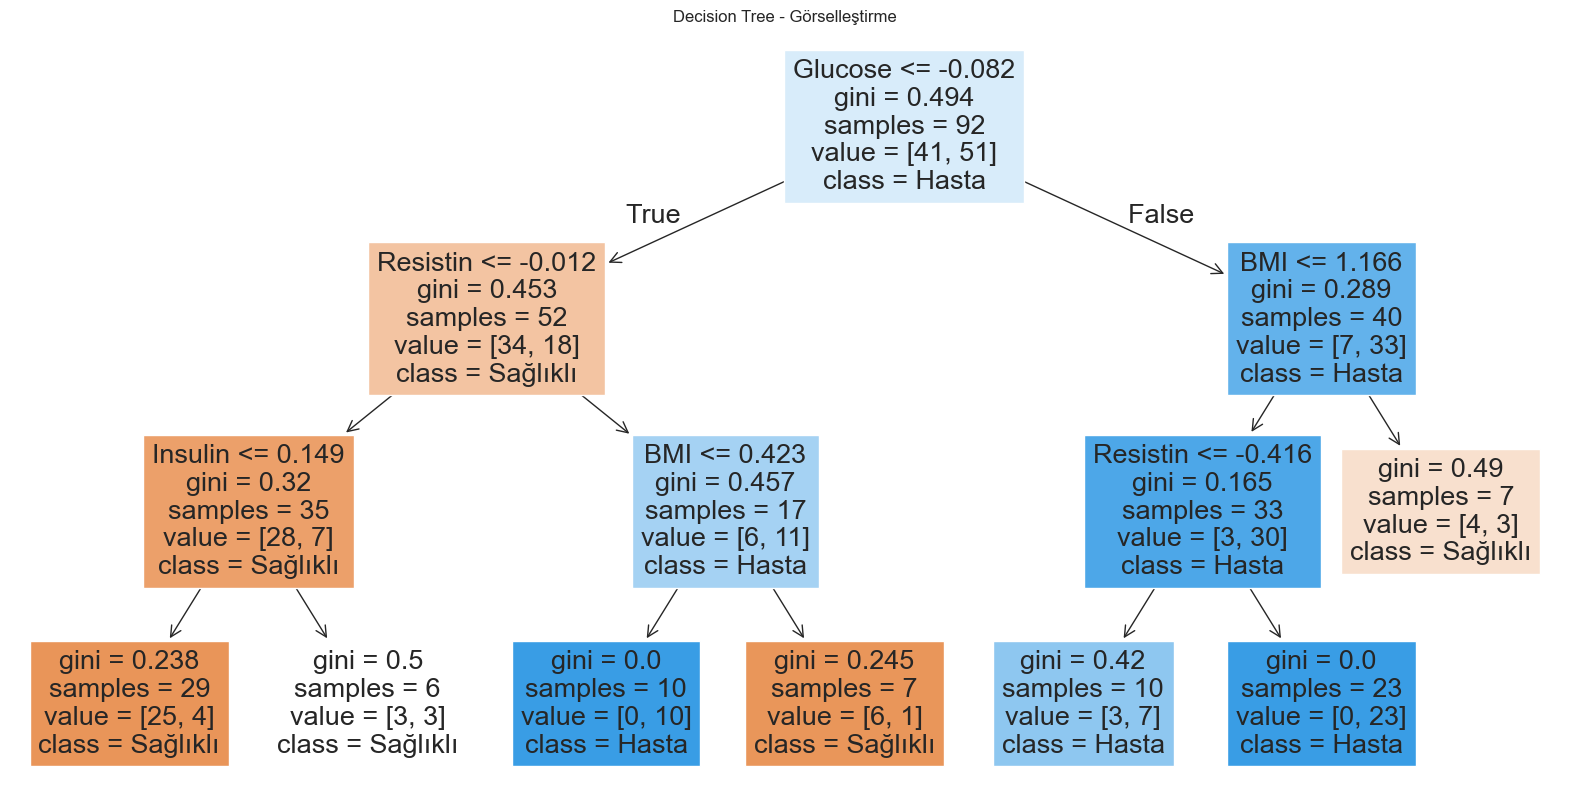

In [58]:
# Decision Tree - tam ağaç
plt.figure(figsize=(20, 10))
tree.plot_tree(best_dt,
               feature_names=secilen_ozellikler,
               class_names=["Sağlıklı", "Hasta"],
               filled=True)
plt.title("Decision Tree - Görselleştirme")
plt.show()

In [59]:
#  SONUÇLARIN YORUMLANMASI
en_iyi_f1  = karsilastirma_df['F1-Score'].idxmax()
en_iyi_acc = karsilastirma_df['Accuracy'].idxmax()

print(f"""
Bu projede Coimbra Meme Kanseri veri seti (116 örnek, 9 özellik)
kullanılarak sağlıklı (0) ve hasta (1) bireylerin tespiti
hedeflenmiştir.

Ön işleme adımında:
  - Sıfır değerler train setinde NaN yapıldı; imputasyon yalnızca train ortalamalarıyla train ve teste uygulandı
  - StandardScaler ile Z-Score normalizasyonu uygulandı
  - ANOVA SelectKBest (k=5) ile en anlamlı 5 özellik seçildi

MODEL KARŞILAŞTIRMA SONUÇLARI:
{karsilastirma_df.round(4).to_string()}

En yüksek F1-Score  : {en_iyi_f1} ({karsilastirma_df.loc[en_iyi_f1,  'F1-Score']:.4f})
En yüksek Accuracy  : {en_iyi_acc} ({karsilastirma_df.loc[en_iyi_acc, 'Accuracy']:.4f})

Tüm modeller GridSearchCV + 5-Fold CV ile optimize edildi.
Overfitting kontrolünde eğitim-test farkı düşük bulundu.
Veri sızıntısını önlemek için imputasyon yalnızca eğitim verisi istatistikleriyle yapılmıştır.


SONUÇ: {en_iyi_f1} algoritması, dengeli precision-recall
değerleri ve en yüksek F1-Score ile bu veri seti için
en başarılı sınıflandırıcı olarak belirlenmiştir.
""")


Bu projede Coimbra Meme Kanseri veri seti (116 örnek, 9 özellik)
kullanılarak sağlıklı (0) ve hasta (1) bireylerin tespiti
hedeflenmiştir.

Ön işleme adımında:
  - Sıfır değerler train setinde NaN yapıldı; imputasyon yalnızca train ortalamalarıyla train ve teste uygulandı
  - StandardScaler ile Z-Score normalizasyonu uygulandı
  - ANOVA SelectKBest (k=5) ile en anlamlı 5 özellik seçildi

MODEL KARŞILAŞTIRMA SONUÇLARI:
               Accuracy  Precision  Recall  F1-Score
Model                                               
Random Forest    0.7083     0.8000  0.6154    0.6957
KNN              0.6250     0.7000  0.5385    0.6087
Naive Bayes      0.6250     0.8333  0.3846    0.5263
Decision Tree    0.7083     0.8000  0.6154    0.6957

En yüksek F1-Score  : Random Forest (0.6957)
En yüksek Accuracy  : Random Forest (0.7083)

Tüm modeller GridSearchCV + 5-Fold CV ile optimize edildi.
Overfitting kontrolünde eğitim-test farkı düşük bulundu.
Veri sızıntısını önlemek için imputasyon yalnızca e

In [60]:
print(f"""
KLİNİK YORUM:
Meme kanseri tespitinde False Negative (hasta bireyi sağlıklı tahmin etmek)
False Positive'e göre çok daha kritiktir. Bu nedenle sadece Accuracy değil,
Recall (Sensitivity) değeri de göz önünde bulundurulmalıdır.
{en_iyi_f1} modeli hem yüksek F1-Score hem de dengeli Recall değeri ile
bu görev için en uygun algoritma olarak öne çıkmaktadır.
""")


KLİNİK YORUM:
Meme kanseri tespitinde False Negative (hasta bireyi sağlıklı tahmin etmek)
False Positive'e göre çok daha kritiktir. Bu nedenle sadece Accuracy değil,
Recall (Sensitivity) değeri de göz önünde bulundurulmalıdır.
Random Forest modeli hem yüksek F1-Score hem de dengeli Recall değeri ile
bu görev için en uygun algoritma olarak öne çıkmaktadır.

